# **AMR CLASSIFICATION FROM FLUORESCENCE MICROSCOPY IMAGES**

## **Environment Setup & Imports**

In [1]:
import os
import shutil
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
import tifffile
import tensorflow as tf

from PIL import Image
from scipy import ndimage as ndi
from sklearn.metrics import confusion_matrix
import json
from skimage import filters, morphology, measure
from skimage.segmentation import clear_border, watershed
from skimage.feature import peak_local_max
from skimage.color import label2rgb

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix,
    classification_report, cohen_kappa_score,
    matthews_corrcoef
)
from sklearn.preprocessing import LabelBinarizer

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    BatchNormalization, Dropout, Input,
    GlobalAveragePooling2D, LayerNormalization,
    MultiHeadAttention, Add
)
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import DenseNet169, EfficientNetB0
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.metrics import F1Score
from tensorflow.keras.preprocessing.image import ImageDataGenerator

warnings.filterwarnings('ignore')

# Plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})

## **Data Acquisition & Preparation**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
filename = "/content/drive/MyDrive/Zips/AMR_Images.zip"

In [4]:
if os.path.exists(filename):
    print(f"Dataset downloaded as {filename}")
else:
    print("Download failed. Check the URL.")

Dataset downloaded as /content/drive/MyDrive/Zips/AMR_Images.zip


In [5]:
import os
if os.path.exists(filename):
    !unzip -q "{filename}" -d "Data"
    print("Extraction complete.")
else:
    print(f"File not found: {filename}")

Extraction complete.


#### **Clean & Rename Folders**

In [6]:
raw_parent_dir = "Data"
CLASSES = ['WT', 'CIP', 'GENT', 'RIF']

# Remove unwanted class
coamox_path = os.path.join(raw_parent_dir, "COAMOX+ETOH")
if os.path.exists(coamox_path):
    shutil.rmtree(coamox_path)
    print("Removed COAMOX+ETOH folder.")

Removed COAMOX+ETOH folder.


In [7]:
# Rename ethanol-suffixed folders
folder_names = ['WT+ETOH', 'CIP+ETOH', 'GENT+ETOH', 'RIF+ETOH']
for f in folder_names:
    old_name = os.path.join(raw_parent_dir, f)
    new_name = os.path.join(raw_parent_dir, f.split("+")[0])
    if os.path.exists(old_name):
        os.rename(old_name, new_name)
    count = len(os.listdir(new_name))
    print(f"  {new_name}: {count} images")

  Data/WT: 455 images
  Data/CIP: 285 images
  Data/GENT: 199 images
  Data/RIF: 279 images


## **Exploratory Data Analysis**

#### **Raw Image Count per Class**

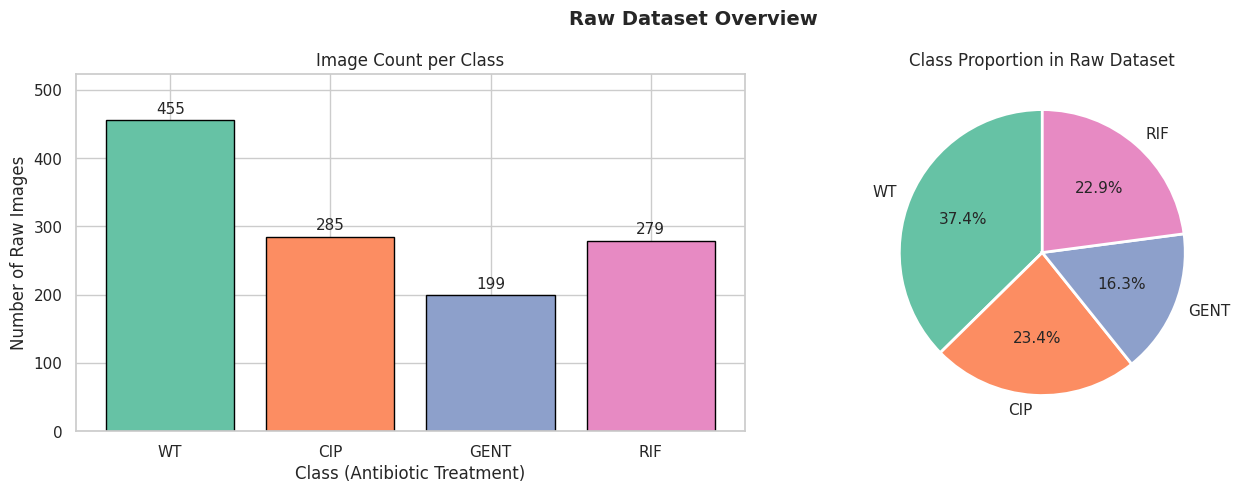

In [8]:
raw_counts = {}
for cls in CLASSES:
    cls_path = os.path.join(raw_parent_dir, cls)
    raw_counts[cls] = len([f for f in os.listdir(cls_path) if f.endswith('.tif')])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Raw Dataset Overview", fontsize=14, fontweight='bold')

# Bar chart
bars = axes[0].bar(raw_counts.keys(), raw_counts.values(),
                   color=sns.color_palette("Set2", len(CLASSES)), edgecolor='black')
axes[0].bar_label(bars, fmt='%d', padding=3, fontsize=11)
axes[0].set_title("Image Count per Class")
axes[0].set_xlabel("Class (Antibiotic Treatment)")
axes[0].set_ylabel("Number of Raw Images")
axes[0].set_ylim(0, max(raw_counts.values()) * 1.15)

# Pie chart
axes[1].pie(
    raw_counts.values(),
    labels=raw_counts.keys(),
    autopct='%1.1f%%',
    colors=sns.color_palette("Set2", len(CLASSES)),
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[1].set_title("Class Proportion in Raw Dataset")

plt.tight_layout()
plt.savefig("raw_class_distribution.png", bbox_inches='tight')
plt.show()

#### **Sample Image per Class**

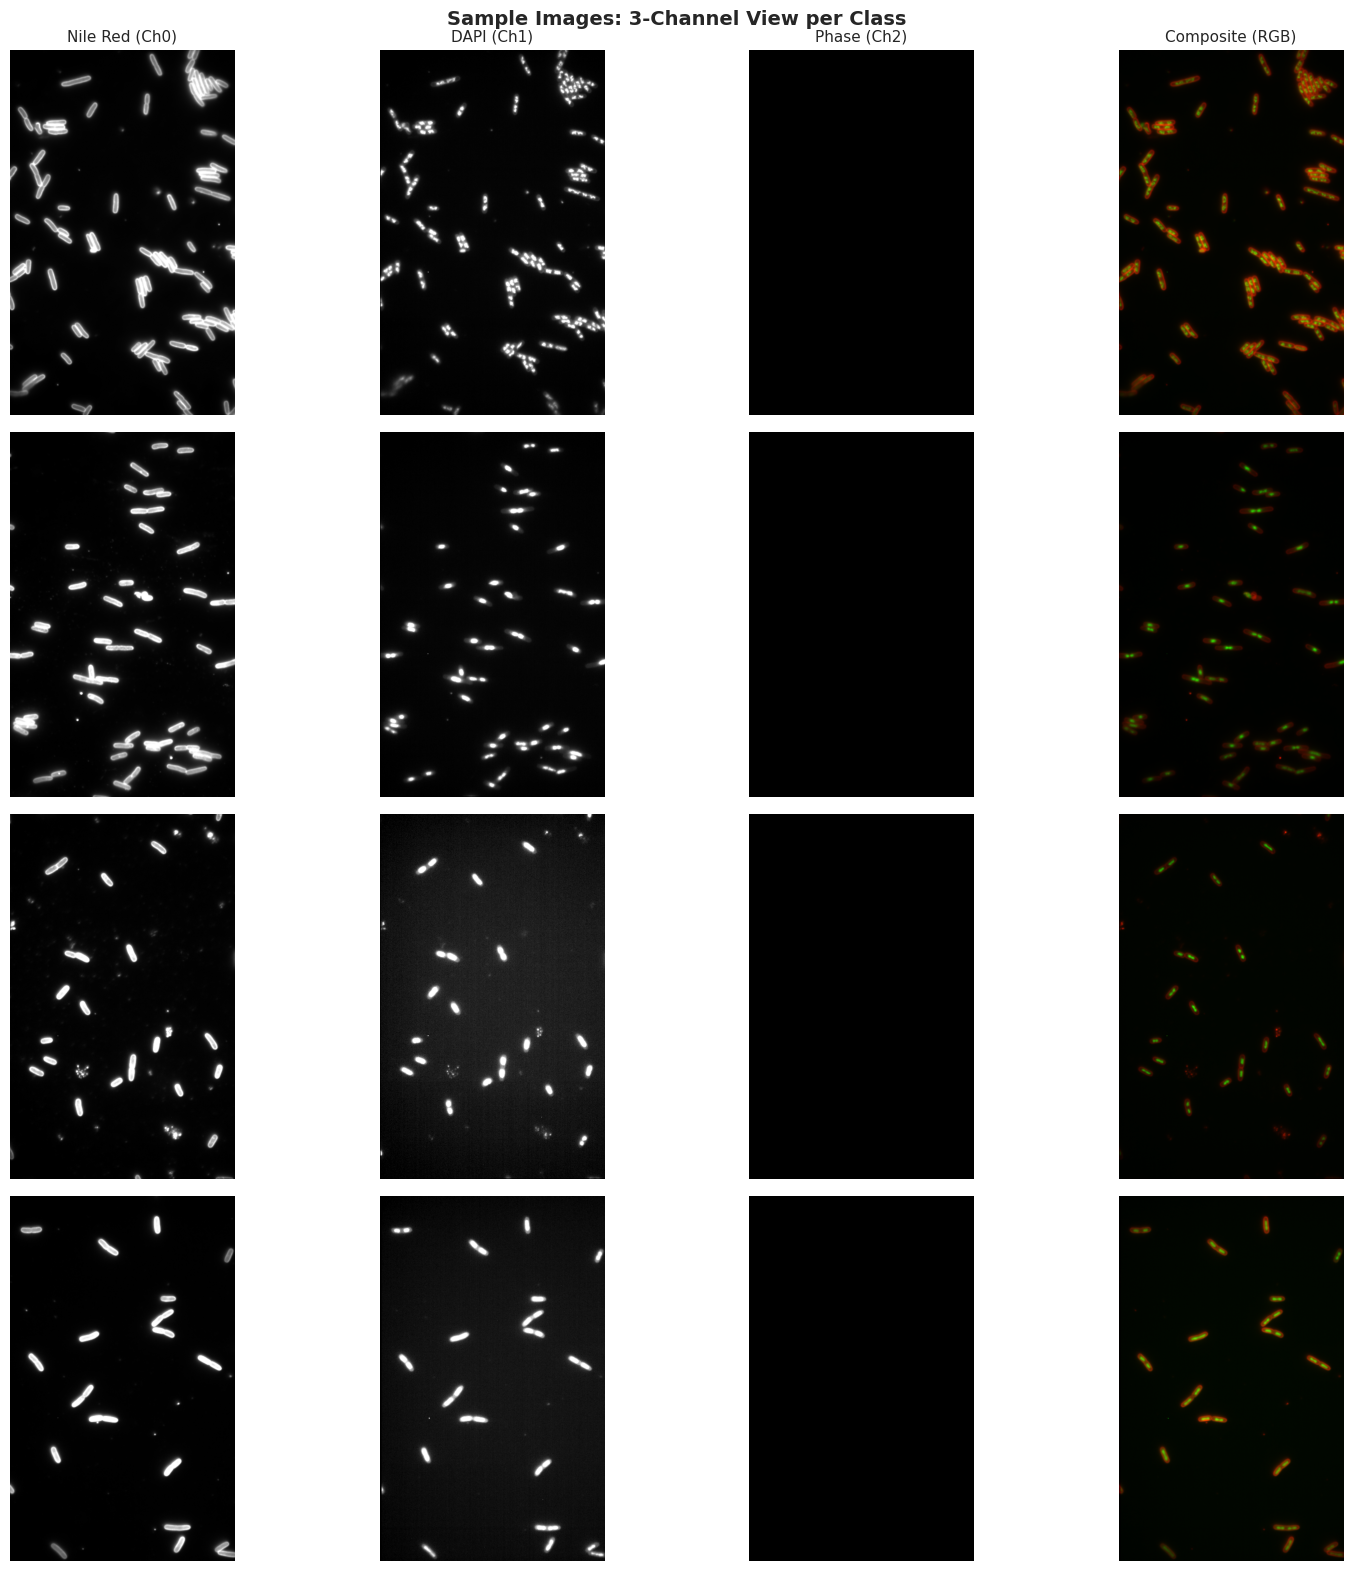

In [9]:
fig, axes = plt.subplots(nrows=len(CLASSES), ncols=4, figsize=(16, 4 * len(CLASSES)))
fig.suptitle("Sample Images: 3-Channel View per Class", fontsize=14, fontweight='bold')

channel_names = ['Nile Red (Ch0)', 'DAPI (Ch1)', 'Phase (Ch2)', 'Composite (RGB)']

for row, cls in enumerate(CLASSES):
    cls_path = os.path.join(raw_parent_dir, cls)
    tifs = [f for f in os.listdir(cls_path) if f.endswith('.tif')]
    img_path = os.path.join(cls_path, random.choice(tifs))
    img = tifffile.imread(img_path)  # shape: (3, H, W)

    for col in range(3):
        ch = img[col].astype(np.float32)
        p1, p99 = np.percentile(ch, (1, 99))
        ch = np.clip(ch, p1, p99)
        ch = (ch - p1) / (p99 - p1 + 1e-8)
        axes[row, col].imshow(ch, cmap='gray')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(channel_names[col], fontsize=11)

    # Composite
    composite = np.transpose(img, (1, 2, 0)).astype(np.float32)
    composite = (composite - composite.min()) / (composite.max() - composite.min() + 1e-8)
    axes[row, 3].imshow(composite)
    axes[row, 3].axis('off')
    if row == 0:
        axes[row, 3].set_title(channel_names[3], fontsize=11)

    axes[row, 0].set_ylabel(cls, fontsize=12, fontweight='bold', labelpad=10)

plt.tight_layout()
plt.savefig("sample_images_per_class.png", bbox_inches='tight')
plt.show()

#### **Pixel Intensity Distribution per Channel per Class**

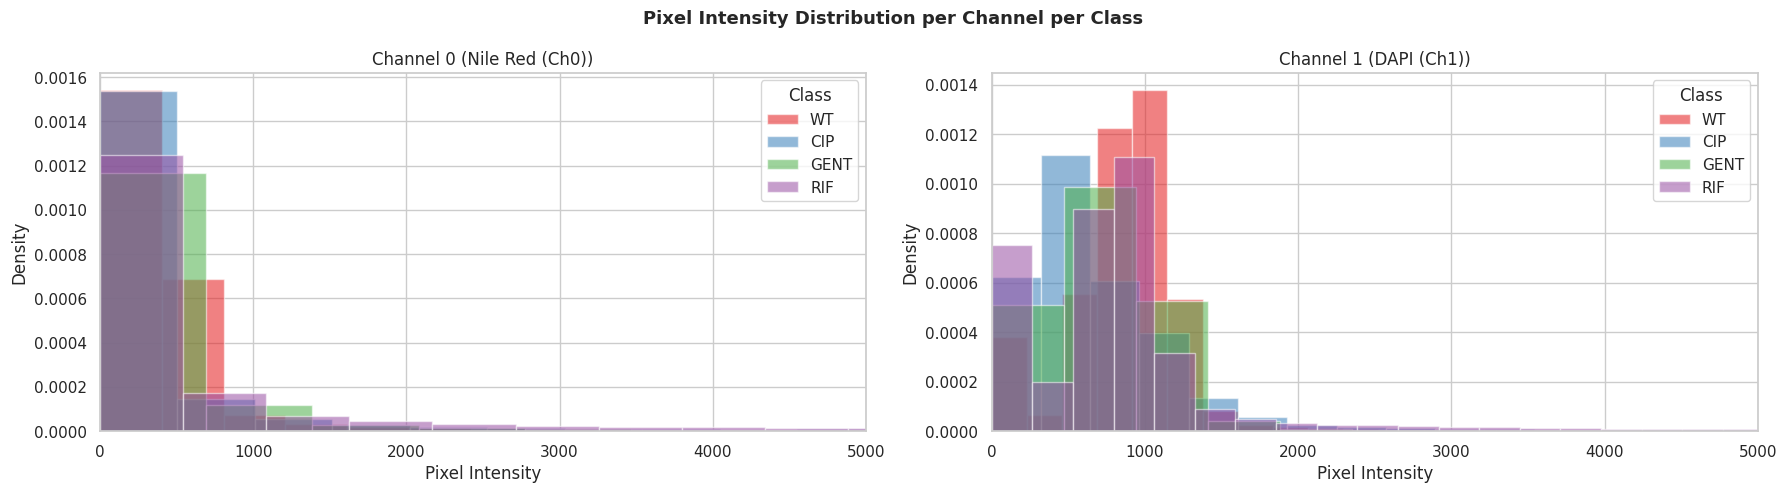

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle("Pixel Intensity Distribution per Channel per Class",
             fontsize=13, fontweight='bold')

palette = sns.color_palette("Set1", len(CLASSES))

channel_names = ['Nile Red (Ch0)', 'DAPI (Ch1)']

for cls_idx, cls in enumerate(CLASSES):
    cls_path = os.path.join(raw_parent_dir, cls)
    tifs = [f for f in os.listdir(cls_path) if f.endswith('.tif')]
    # Sample up to 10 images for speed
    sampled = random.sample(tifs, min(10, len(tifs)))

    # Per-channel histogram
    for ch_idx in range(2):
        ch_pixels = []
        for fn in sampled:
            img = tifffile.imread(os.path.join(cls_path, fn))
            ch = img[ch_idx].flatten().astype(np.float32)
            # store a sample of pixels to avoid memory issues with very large datasets
            ch_pixels.extend(ch[:3000].tolist())

        axes[ch_idx].hist(
            ch_pixels, bins=80, alpha=0.55,
            label=cls, color=palette[cls_idx], density=True
        )
        axes[ch_idx].set_title(f"Channel {ch_idx} ({channel_names[ch_idx]})")
        axes[ch_idx].set_xlabel("Pixel Intensity")
        axes[ch_idx].set_ylabel("Density")
        axes[ch_idx].set_xlim(0, 5000)

for ax in axes:
    ax.legend(title="Class")

plt.tight_layout()
plt.savefig("pixel_intensity_distribution.png", bbox_inches='tight')
plt.show()

#### **Morphological Feature EDA (Cell Area & Eccentricity)**

In [11]:
CLAHE_eda = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def quick_segment(nile_img):
    nile = cv2.normalize(nile_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    enhanced = CLAHE_eda.apply(nile)
    blur = cv2.GaussianBlur(enhanced, (3, 3), 0)
    adaptive = cv2.adaptiveThreshold(blur, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 51, 5)
    binary = adaptive.astype(bool)
    binary = morphology.remove_small_objects(binary, min_size=100)
    binary = morphology.remove_small_holes(binary, area_threshold=100)
    binary = clear_border(binary)
    if np.sum(binary) == 0:
        return None
    distance = ndi.distance_transform_edt(binary)
    local_max = peak_local_max(distance, min_distance=10, labels=binary)
    markers = np.zeros_like(distance, dtype=np.int32)
    markers[tuple(local_max.T)] = np.arange(1, len(local_max) + 1)
    labels = watershed(-distance, markers, mask=binary)
    return labels

morph_data = []
for cls in CLASSES:
    cls_path = os.path.join(raw_parent_dir, cls)
    tifs = [f for f in os.listdir(cls_path) if f.endswith('.tif')]
    for fn in random.sample(tifs, min(5, len(tifs))):
        img = tifffile.imread(os.path.join(cls_path, fn))
        labels = quick_segment(img[0])
        if labels is None:
            continue
        for region in measure.regionprops(labels):
            if region.area >= 200:
                morph_data.append({
                    'class': cls,
                    'area': region.area,
                    'eccentricity': region.eccentricity,
                    'perimeter': region.perimeter,
                    'major_axis': region.major_axis_length,
                    'minor_axis': region.minor_axis_length,
                    'solidity': region.solidity
                })

morph_df = pd.DataFrame(morph_data)
print(f"  Extracted morphological features from {len(morph_df)} cells.")

  Extracted morphological features from 872 cells.


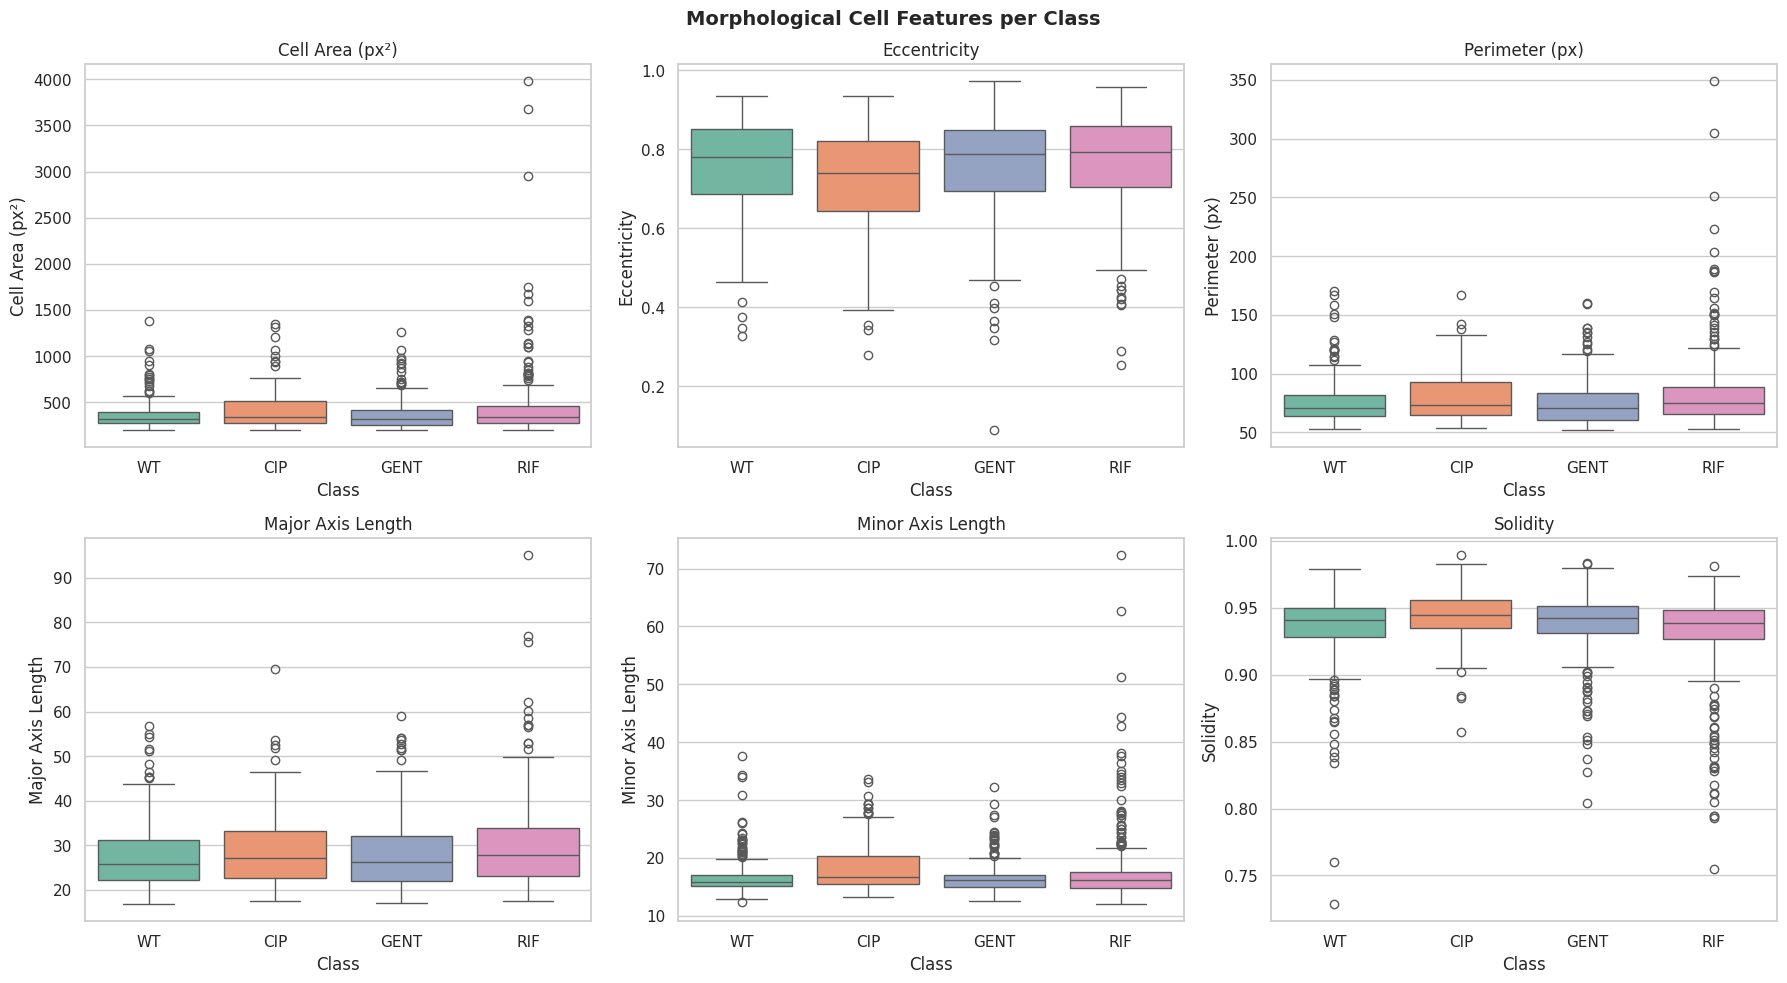

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Morphological Cell Features per Class", fontsize=14, fontweight='bold')

features = ['area', 'eccentricity', 'perimeter', 'major_axis', 'minor_axis', 'solidity']
feat_labels = ['Cell Area (px²)', 'Eccentricity', 'Perimeter (px)',
               'Major Axis Length', 'Minor Axis Length', 'Solidity']

for ax, feat, lbl in zip(axes.flat, features, feat_labels):
    sns.boxplot(data=morph_df, x='class', y=feat, palette='Set2', ax=ax, order=CLASSES)
    ax.set_title(lbl)
    ax.set_xlabel("Class")
    ax.set_ylabel(lbl)

plt.tight_layout()
plt.savefig("morphological_features.png", bbox_inches='tight')
plt.show()

#### **Correlation Heatmap**

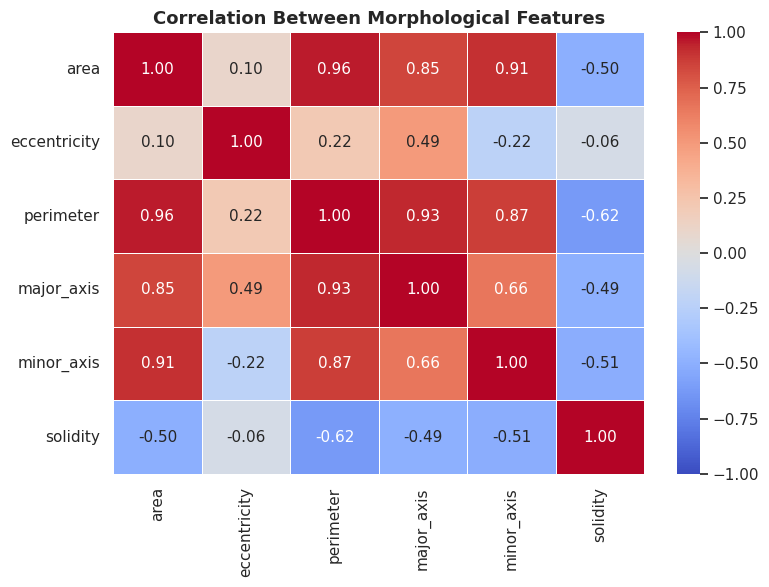

In [14]:
corr_cols = ['area', 'eccentricity', 'perimeter', 'major_axis', 'minor_axis', 'solidity']
corr_matrix = morph_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title("Correlation Between Morphological Features", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("feature_correlation_heatmap.png", bbox_inches='tight')
plt.show()

#### **Violin Plot -> Cell count per image per class**

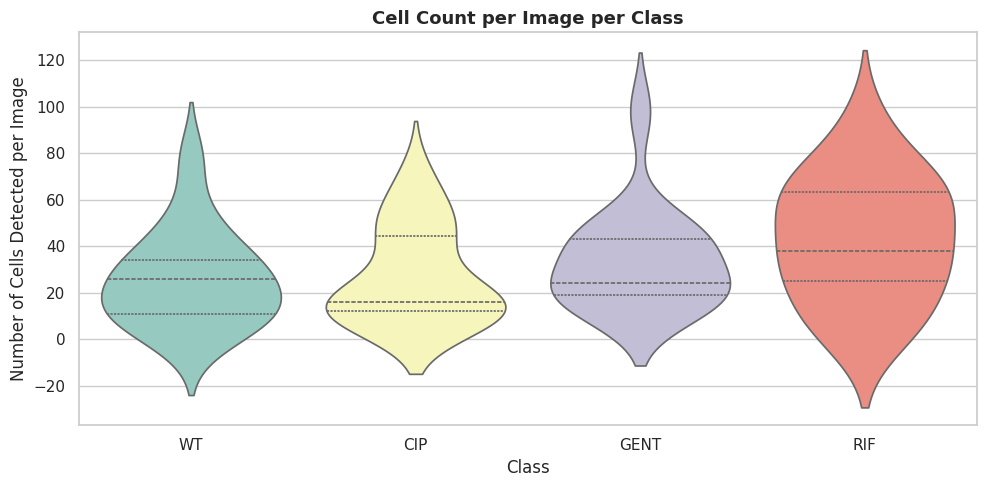

In [15]:
cell_count_data = []
for cls in CLASSES:
    cls_path = os.path.join(raw_parent_dir, cls)
    tifs = [f for f in os.listdir(cls_path) if f.endswith('.tif')]
    for fn in random.sample(tifs, min(15, len(tifs))):
        img = tifffile.imread(os.path.join(cls_path, fn))
        labels = quick_segment(img[0])
        if labels is None:
            count = 0
        else:
            count = len([r for r in measure.regionprops(labels) if r.area >= 200])
        cell_count_data.append({'class': cls, 'cell_count': count})

cell_count_df = pd.DataFrame(cell_count_data)

fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(data=cell_count_df, x='class', y='cell_count',
               palette='Set3', order=CLASSES, inner='quartile', ax=ax)
ax.set_title("Cell Count per Image per Class", fontsize=13, fontweight='bold')
ax.set_xlabel("Class")
ax.set_ylabel("Number of Cells Detected per Image")
plt.tight_layout()
plt.savefig("cell_count_violin.png", bbox_inches='tight')
plt.show()

## **Data Splitting**

In [16]:
source_dir = raw_parent_dir
target_dir = "intermediate"
SPLITS = ["train", "val", "test"]

for split in SPLITS:
    for cls in CLASSES:
        os.makedirs(os.path.join(target_dir, split, cls), exist_ok=True)

train_ratio, val_ratio, test_ratio = 0.70, 0.15, 0.15

In [17]:
split_summary = {}
for cls in CLASSES:
    cls_path = os.path.join(source_dir, cls)
    images = [f for f in os.listdir(cls_path) if f.endswith('.tif')]
    random.shuffle(images)

    total = len(images)
    train_end = int(train_ratio * total)
    val_end   = train_end + int(val_ratio * total)

    sets = {
        'train': images[:train_end],
        'val':   images[train_end:val_end],
        'test':  images[val_end:]
    }
    split_summary[cls] = {s: len(v) for s, v in sets.items()}

    for split_name, imgs in sets.items():
        for img_file in imgs:
            shutil.copy2(
                os.path.join(cls_path, img_file),
                os.path.join(target_dir, split_name, cls, img_file)
            )

In [18]:
print("\nSplit Summary:")
split_df = pd.DataFrame(split_summary).T
split_df.columns.name = 'Split'
print(split_df)


Split Summary:
Split  train  val  test
WT       318   68    69
CIP      199   42    44
GENT     139   29    31
RIF      195   41    43


## **Cell Segmentation**

In [19]:
BASE_PATH   = "intermediate"
DST_PATH    = "segmented images"
NILE_CH     = 0
MIN_AREA    = 200
RESIZE      = 128
CLAHE_seg   = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

In [20]:
def pad_to_square(img):
    h, w, c = img.shape
    size = max(h, w)
    padded = np.zeros((size, size, c), dtype=img.dtype)
    y_off = (size - h) // 2
    x_off = (size - w) // 2
    padded[y_off:y_off+h, x_off:x_off+w] = img
    return padded

In [21]:
def segment_cells(nile_img):
    nile     = cv2.normalize(nile_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    enhanced = CLAHE_seg.apply(nile)
    blur     = cv2.GaussianBlur(enhanced, (3, 3), 0)
    adaptive = cv2.adaptiveThreshold(
        blur, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 51, 5
    )
    binary = adaptive.astype(bool)
    binary = morphology.remove_small_objects(binary, min_size=100)
    binary = morphology.remove_small_holes(binary, area_threshold=100)
    binary = clear_border(binary)
    if np.sum(binary) == 0:
        return None
    distance  = ndi.distance_transform_edt(binary)
    local_max = peak_local_max(distance, min_distance=10, labels=binary)
    markers   = np.zeros_like(distance, dtype=np.int32)
    markers[tuple(local_max.T)] = np.arange(1, len(local_max) + 1)
    labels = watershed(-distance, markers, mask=binary)
    return labels

In [22]:
segmentation_summary = {s: {c: 0 for c in CLASSES} for s in SPLITS}

for split in SPLITS:
    print(f"\n  Processing {split} split...")
    input_split  = os.path.join(BASE_PATH, split)
    output_split = os.path.join(DST_PATH, f"{split}_segmented")

    for cls in CLASSES:
        input_cls  = os.path.join(input_split, cls)
        output_cls = os.path.join(output_split, cls)
        os.makedirs(output_cls, exist_ok=True)

        images = [f for f in os.listdir(input_cls) if f.endswith('.tif')]
        cell_id = 0

        for img_name in images:
            img_path = os.path.join(input_cls, img_name)
            try:
                img = tifffile.imread(img_path)
            except Exception:
                continue

            labels = segment_cells(img[NILE_CH])
            if labels is None:
                continue

            full_img = np.transpose(img, (1, 2, 0))

            for region in measure.regionprops(labels):
                if region.area < MIN_AREA:
                    continue
                if region.eccentricity < 0.6:
                    continue

                minr, minc, maxr, maxc = region.bbox
                crop = full_img[minr:maxr, minc:maxc].copy()
                mask = (labels[minr:maxr, minc:maxc] == region.label)
                crop[~mask] = 0

                crop = pad_to_square(crop)
                crop = cv2.resize(crop, (RESIZE, RESIZE))

                save_name = f"{cls}_{img_name[:-4]}_cell_{cell_id}.png"
                cv2.imwrite(
                    os.path.join(output_cls, save_name),
                    cv2.cvtColor(crop, cv2.COLOR_RGB2BGR)
                )
                cell_id += 1

        segmentation_summary[split][cls] = cell_id
        print(f"    {cls}: {cell_id} cells saved")


  Processing train split...
    WT: 11746 cells saved
    CIP: 6887 cells saved
    GENT: 6252 cells saved
    RIF: 8916 cells saved

  Processing val split...
    WT: 2793 cells saved
    CIP: 1460 cells saved
    GENT: 1107 cells saved
    RIF: 1853 cells saved

  Processing test split...
    WT: 2477 cells saved
    CIP: 1400 cells saved
    GENT: 1419 cells saved
    RIF: 1587 cells saved


In [23]:
# Segmented cell count bar chart
seg_df = pd.DataFrame(segmentation_summary).T
print("\nSegmented Cell Counts:")
print(seg_df)


Segmented Cell Counts:
          WT   CIP  GENT   RIF
train  11746  6887  6252  8916
val     2793  1460  1107  1853
test    2477  1400  1419  1587


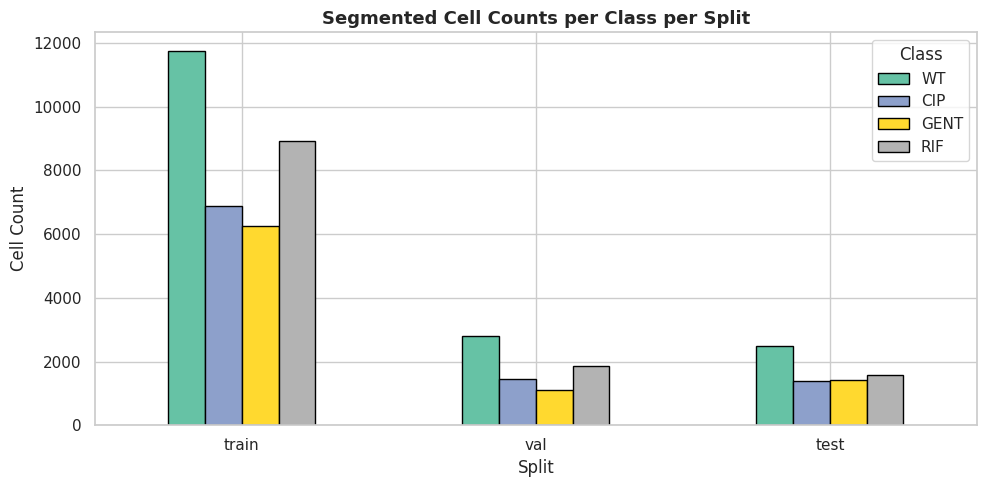

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
seg_df.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black')
ax.set_title("Segmented Cell Counts per Class per Split", fontsize=13, fontweight='bold')
ax.set_xlabel("Split")
ax.set_ylabel("Cell Count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Class')
plt.tight_layout()
plt.savefig("segmentation_cell_counts.png", bbox_inches='tight')
plt.show()

## **Data Loaders & Augmentation**

In [25]:
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.15,
    shear_range=0.1,
    brightness_range=[0.85, 1.15],
    fill_mode='reflect'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    'segmented images/train_segmented',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_test_datagen.flow_from_directory(
    'segmented images/val_segmented',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    'segmented images/test_segmented',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 33801 images belonging to 4 classes.
Found 7213 images belonging to 4 classes.
Found 6883 images belonging to 4 classes.


In [26]:
CLASS_NAMES = list(train_gen.class_indices.keys())
NUM_CLASSES = train_gen.num_classes
print(f"\nClasses : {CLASS_NAMES}")
print(f"Train   : {train_gen.samples} images")
print(f"Val     : {val_gen.samples} images")
print(f"Test    : {test_gen.samples} images")


Classes : ['CIP', 'GENT', 'RIF', 'WT']
Train   : 33801 images
Val     : 7213 images
Test    : 6883 images


In [27]:
# Class weights for imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights_dict = dict(enumerate(class_weights))
print(f"\nClass Weights: {class_weights_dict}")


Class Weights: {0: np.float64(1.2269856250907507), 1: np.float64(1.3516074856046065), 2: np.float64(0.9477624495289367), 3: np.float64(0.7194151200408649)}


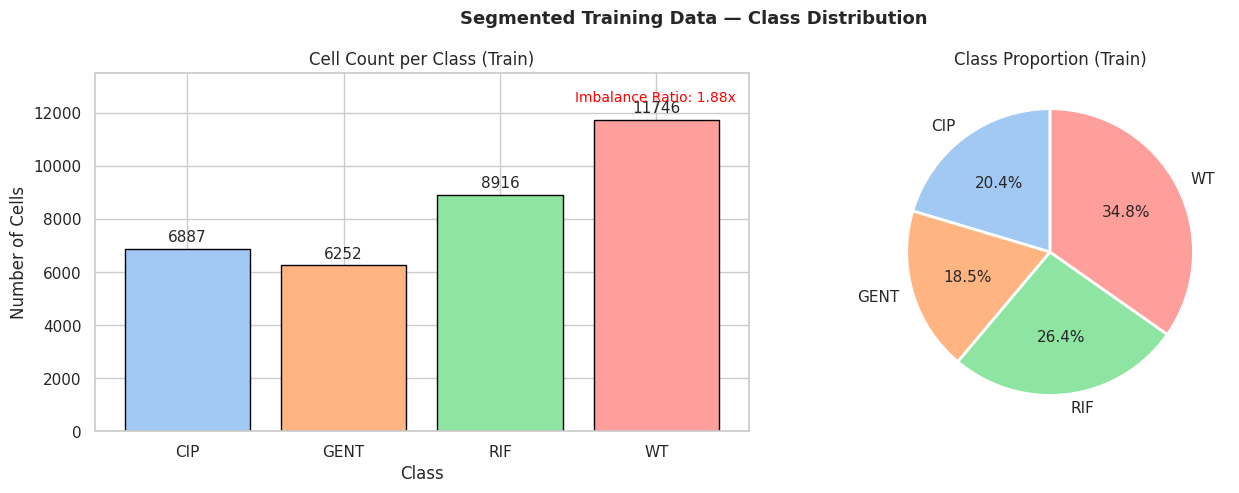

In [28]:
seg_train_counts = {cls: len(os.listdir(os.path.join('segmented images/train_segmented', cls)))
                    for cls in CLASS_NAMES}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Segmented Training Data — Class Distribution", fontsize=13, fontweight='bold')

bars = axes[0].bar(seg_train_counts.keys(), seg_train_counts.values(),
                   color=sns.color_palette("pastel", NUM_CLASSES), edgecolor='black')
axes[0].bar_label(bars, fmt='%d', padding=3)
axes[0].set_title("Cell Count per Class (Train)")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Cells")

counts_arr = np.array(list(seg_train_counts.values()))
imbalance_ratio = counts_arr.max() / counts_arr.min()
axes[0].set_ylim(0, counts_arr.max() * 1.15)
axes[0].text(0.98, 0.95, f"Imbalance Ratio: {imbalance_ratio:.2f}x",
             transform=axes[0].transAxes, ha='right', va='top',
             fontsize=10, color='red')

axes[1].pie(
    seg_train_counts.values(),
    labels=seg_train_counts.keys(),
    autopct='%1.1f%%',
    colors=sns.color_palette("pastel", NUM_CLASSES),
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[1].set_title("Class Proportion (Train)")

plt.tight_layout()
plt.savefig("segmented_train_distribution.png", bbox_inches='tight')
plt.show()

## **Evaluation Metrics Function**

In [29]:
all_metrics = []

def full_evaluate(model, model_name, generator, class_names):
    generator.reset()
    results = model.evaluate(generator, verbose=0)
    preds   = model.predict(generator, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    true_labels = generator.classes

    kappa = cohen_kappa_score(true_labels, pred_labels)
    mcc   = matthews_corrcoef(true_labels, pred_labels)

    return {
        'Model':     model_name,
        'Loss':      round(results[0], 4),
        'Accuracy':  round(results[1], 4),
        'Precision': round(results[2], 4),
        'Recall':    round(results[3], 4),
        'F1-Score':  round(results[4], 4),
        'Cohen Kappa': round(kappa, 4),
        'MCC':       round(mcc, 4),
        '_preds':    preds,
        '_pred_labels': pred_labels,
        '_true_labels': true_labels
    }

## **Model Definitions**

In [30]:
EPOCHS = 25

# Callbacks
def get_callbacks(model_tag):
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1
    )
    checkpoint = ModelCheckpoint(
        filepath=f"best_{model_tag}.keras",
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    )
    return [reduce_lr, checkpoint]

#### **Custom CNN**

In [ ]:
def build_cnn(num_classes, input_shape=(128, 128, 3)):
    model = Sequential([
        Input(shape=input_shape),
        # Block 1
        Conv2D(32, 3, activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(32, 3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2),
        Dropout(0.25),
        # Block 2
        Conv2D(64, 3, activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, 3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2),
        Dropout(0.25),
        # Block 3
        Conv2D(128, 3, activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, 3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2),
        Dropout(0.30),
        # Block 4
        Conv2D(256, 3, activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, 3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2),
        Dropout(0.40),
        # Classifier head
        GlobalAveragePooling2D(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.50),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.30),
        Dense(num_classes, activation='softmax')
    ], name='CustomCNN')
    return model

In [ ]:
cnn_model = build_cnn(NUM_CLASSES)
cnn_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall', F1Score(average='macro')]
)

# cnn_model.summary()

In [ ]:
cnn_history = cnn_model.fit(
    train_gen, epochs=EPOCHS,
    validation_data=val_gen,
    class_weight=class_weights_dict,
    callbacks=get_callbacks('cnn'), verbose=1
)

Epoch 1/25
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.3705 - f1_score: 0.3687 - loss: 1.6473 - precision: 0.3925 - recall: 0.2825
Epoch 1: val_accuracy improved from None to 0.27055, saving model to best_cnn.keras

Epoch 1: finished saving model to best_cnn.keras
535/535 ━━━━━━━━━━━━━━━━━━━━ 297s 505ms/step - accuracy: 0.4007 - f1_score: 0.3990 - loss: 1.5250 - precision: 0.4269 - recall: 0.3071 - val_accuracy: 0.2705 - val_f1_score: 0.1869 - val_loss: 2.2476 - val_precision: 0.2705 - val_recall: 0.2435 - learning_rate: 1.0000e-04
Epoch 2/25
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.4435 - f1_score: 0.4419 - loss: 1.3391 - precision: 0.4845 - recall: 0.3426
Epoch 2: val_accuracy improved from 0.27055 to 0.38077, saving model to best_cnn.keras

Epoch 2: finished saving model to best_cnn.keras
535/535 ━━━━━━━━━━━━━━━━━━━━ 241s 451ms/step - accuracy: 0.4544 - f1_score: 0.4528 - loss: 1.3051 - precision: 0.4949 - recall: 0.3507 - val_accuracy: 0.3808 - val_f1_s

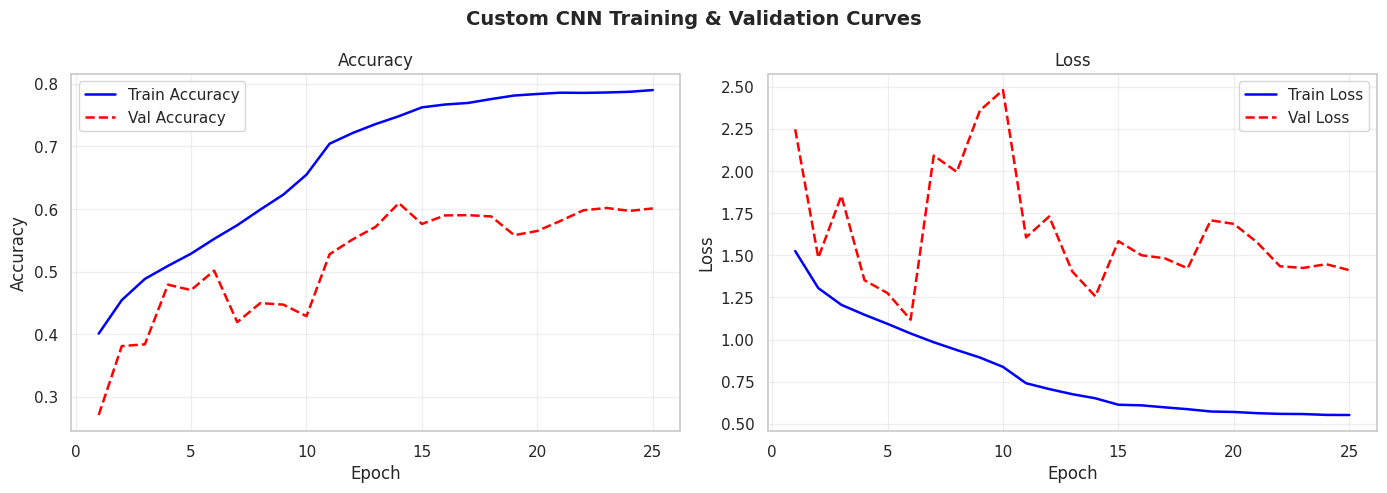

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Custom CNN Training & Validation Curves", fontsize=14, fontweight='bold')

hist = cnn_history.history
epochs_ran = range(1, len(hist['accuracy']) + 1)

axes[0].plot(epochs_ran, hist['accuracy'], label='Train Accuracy', color='blue', linewidth=1.8)
axes[0].plot(epochs_ran, hist['val_accuracy'], label='Val Accuracy', color='red', linestyle='--', linewidth=1.8)
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, hist['loss'], label='Train Loss', color='blue', linewidth=1.8)
axes[1].plot(epochs_ran, hist['val_loss'], label='Val Loss', color='red', linestyle='--', linewidth=1.8)
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cnn_training_curves.png", bbox_inches='tight')
plt.show()


In [ ]:
cnn_history_dict = cnn_history.history

for key, value_list in cnn_history_dict.items():
    cnn_history_dict[key] = [float(val) for val in value_list]

In [ ]:
with open('cnn_history.json', 'w') as f:
    json.dump(cnn_history_dict, f, indent=4)
print("CNN training history saved to cnn_history.json")

CNN training history saved to cnn_history.json


In [ ]:
print("  Calculating evaluation metrics for Custom CNN...")
cnn_eval_metrics = full_evaluate(cnn_model, 'Custom CNN', test_gen, CLASS_NAMES)

json_friendly_cnn_metrics = {k: v for k, v in cnn_eval_metrics.items()} # if not k.startswith('_')}

  Calculating evaluation metrics for Custom CNN...


In [ ]:
json_serializable_cnn_metrics = json_friendly_cnn_metrics.copy()

# Convert numpy arrays to lists and numpy floats to Python floats for JSON serialization
for key, value in json_serializable_cnn_metrics.items():
    if isinstance(value, np.ndarray):
        json_serializable_cnn_metrics[key] = value.tolist()
    elif isinstance(value, (np.float32, np.float64, np.int64)):
        json_serializable_cnn_metrics[key] = float(value)

In [ ]:
json_filename = 'cnn_model_metrics.json'
with open(json_filename, 'w') as f:
    json.dump(json_serializable_cnn_metrics, f, indent=4)
print(f"\nCustom CNN evaluation metrics saved to {json_filename}")


Custom CNN evaluation metrics saved to cnn_model_metrics.json


In [ ]:
cnn_metrics_df = pd.DataFrame([json_friendly_cnn_metrics])
cnn_metrics_df

,Model,Loss,Accuracy,Precision,Recall,F1-Score,Cohen Kappa,MCC,_preds,_pred_labels,_true_labels
0,Custom CNN,1.1857,0.6403,0.6552,0.6218,0.5877,0.5132,0.5408,"[[0.0270458, 0.23074079, 0.7402469, 0.00196647...","[2, 2, 2, 1, 1, 2, 1, 1, 0, 1, 1, 1, 2, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [ ]:
metrics_to_plot = cnn_metrics_df.drop(columns=['Model'], errors='ignore')
metrics_to_plot = metrics_to_plot.loc[:, ~metrics_to_plot.columns.str.startswith('_')]

metric_names = metrics_to_plot.columns.tolist()
metric_values = metrics_to_plot.iloc[0].tolist()

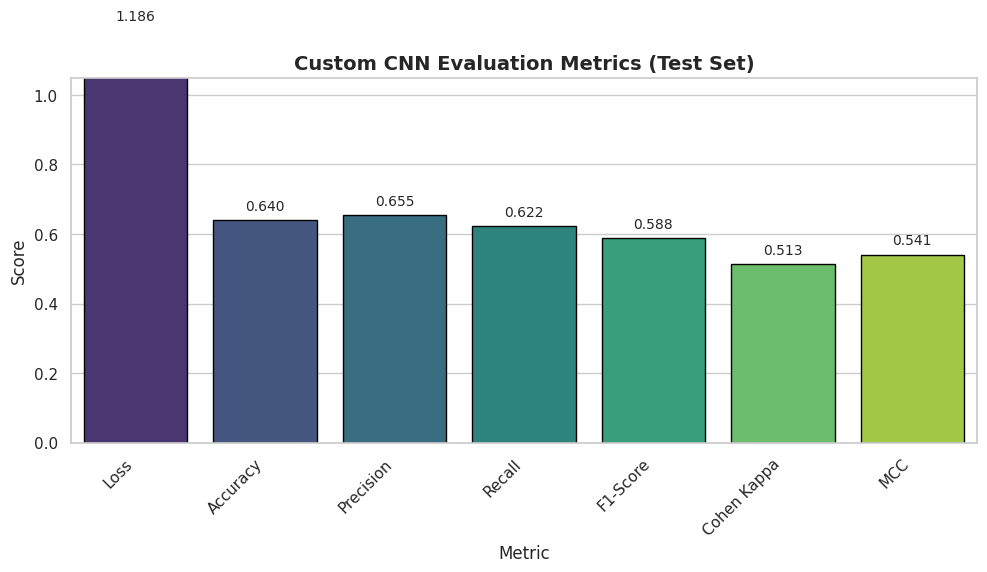

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=metric_names, y=metric_values, palette='viridis', edgecolor='black')

plt.title('Custom CNN Evaluation Metrics (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.ylim(0, 1.50)
plt.xticks(rotation=45, ha='right')

for index, value in enumerate(metric_values):
    plt.text(index, value + 0.02, f'{value:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('cnn_metrics_bar_chart.png', bbox_inches='tight')
plt.show()

#### **DenseNet169**

In [ ]:
def build_densenet(num_classes, input_shape=(128, 128, 3)):
    base = DenseNet169(include_top=False, weights='imagenet', input_shape=input_shape)
    # Fine-tune top 30 layers
    for layer in base.layers[:-30]:
        layer.trainable = False
    for layer in base.layers[-30:]:
        layer.trainable = True

    x = GlobalAveragePooling2D()(base.output)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    out = Dense(num_classes, activation='softmax')(x)
    return Model(inputs=base.input, outputs=out, name='DenseNet169_FT')

In [ ]:
densenet_model = build_densenet(NUM_CLASSES)
densenet_model.compile(
    optimizer=Adam(learning_rate=5e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall', F1Score(average='macro')]
)
# densenet_model.summary()

51877672/51877672 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
densenet_history = densenet_model.fit(
    train_gen, epochs=EPOCHS,
    validation_data=val_gen,
    class_weight=class_weights_dict,
    callbacks=get_callbacks('densenet'), verbose=1
)

Epoch 1/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.3549 - f1_score: 0.3515 - loss: 1.7732 - precision: 0.3776 - recall: 0.2817
Epoch 1: val_accuracy improved from None to 0.66472, saving model to best_densenet.keras

Epoch 1: finished saving model to best_densenet.keras
511/511 ━━━━━━━━━━━━━━━━━━━━ 367s 607ms/step - accuracy: 0.4198 - f1_score: 0.4147 - loss: 1.5662 - precision: 0.4515 - recall: 0.3467 - val_accuracy: 0.6647 - val_f1_score: 0.6430 - val_loss: 0.8471 - val_precision: 0.7397 - val_recall: 0.5710 - learning_rate: 5.0000e-05
Epoch 2/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.5308 - f1_score: 0.5206 - loss: 1.2566 - precision: 0.5726 - recall: 0.4706
Epoch 2: val_accuracy improved from 0.66472 to 0.70980, saving model to best_densenet.keras

Epoch 2: finished saving model to best_densenet.keras
511/511 ━━━━━━━━━━━━━━━━━━━━ 229s 448ms/step - accuracy: 0.5525 - f1_score: 0.5419 - loss: 1.2003 - precision: 0.5943 - recall: 0.4930 - val_accurac

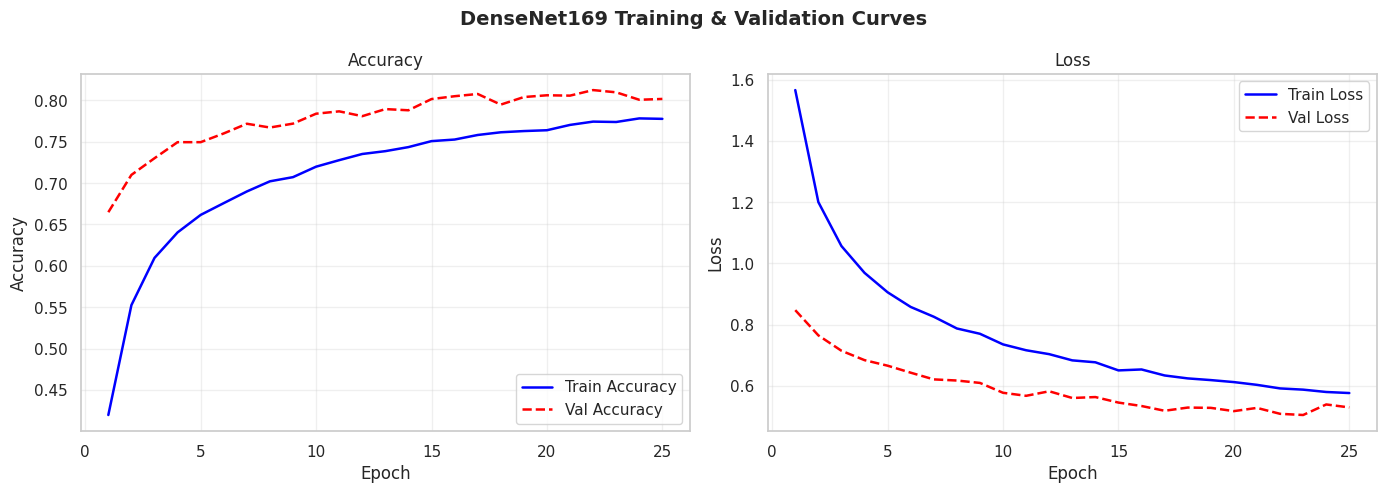

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("DenseNet169 Training & Validation Curves", fontsize=14, fontweight='bold')

hist = densenet_history.history
epochs_ran = range(1, len(hist['accuracy']) + 1)

axes[0].plot(epochs_ran, hist['accuracy'], label='Train Accuracy', color='blue', linewidth=1.8)
axes[0].plot(epochs_ran, hist['val_accuracy'], label='Val Accuracy', color='red', linestyle='--', linewidth=1.8)
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, hist['loss'], label='Train Loss', color='blue', linewidth=1.8)
axes[1].plot(epochs_ran, hist['val_loss'], label='Val Loss', color='red', linestyle='--', linewidth=1.8)
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("densenet_training_curves.png", bbox_inches='tight')
plt.show()

In [ ]:
densenet_history_dict = densenet_history.history
for key, value_list in densenet_history_dict.items():
    densenet_history_dict[key] = [float(val) for val in value_list]

In [ ]:
with open('densenet_history.json', 'w') as f:
    json.dump(densenet_history_dict, f, indent=4)
print("DenseNet training history saved to densenet_history.json")

DenseNet training history saved to densenet_history.json


In [ ]:
print("  Calculating evaluation metrics for DenseNet169...")
densenet_eval_metrics = full_evaluate(densenet_model, 'DenseNet169', test_gen, CLASS_NAMES)

json_friendly_densenet_metrics = densenet_eval_metrics.copy()

  Calculating evaluation metrics for DenseNet169...


In [ ]:
json_serializable_densenet_metrics = json_friendly_densenet_metrics.copy()

for key, value in json_serializable_densenet_metrics.items():
    if isinstance(value, np.ndarray):
        json_serializable_densenet_metrics[key] = value.tolist()
    elif isinstance(value, (np.float32, np.float64, np.int64)):
        json_serializable_densenet_metrics[key] = float(value)

In [ ]:
json_filename = 'densenet_model_metrics.json'
with open(json_filename, 'w') as f:
    json.dump(json_serializable_densenet_metrics, f, indent=4)
print(f"\nDenseNet169 evaluation metrics saved to {json_filename}")


DenseNet169 evaluation metrics saved to densenet_model_metrics.json


In [ ]:
densenet_metrics_df = pd.DataFrame([json_friendly_densenet_metrics])
densenet_metrics_df

,Model,Loss,Accuracy,Precision,Recall,F1-Score,Cohen Kappa,MCC,_preds,_pred_labels,_true_labels
0,DenseNet169,0.5336,0.7948,0.8327,0.7535,0.784,0.7206,0.7218,"[[0.98924375, 0.010666784, 1.2523972e-06, 8.81...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [ ]:
metrics_to_plot = densenet_metrics_df.drop(columns=['Model'], errors='ignore')
metrics_to_plot = metrics_to_plot.loc[:, ~metrics_to_plot.columns.str.startswith('_')]

metric_names = metrics_to_plot.columns.tolist()
metric_values = metrics_to_plot.iloc[0].tolist()

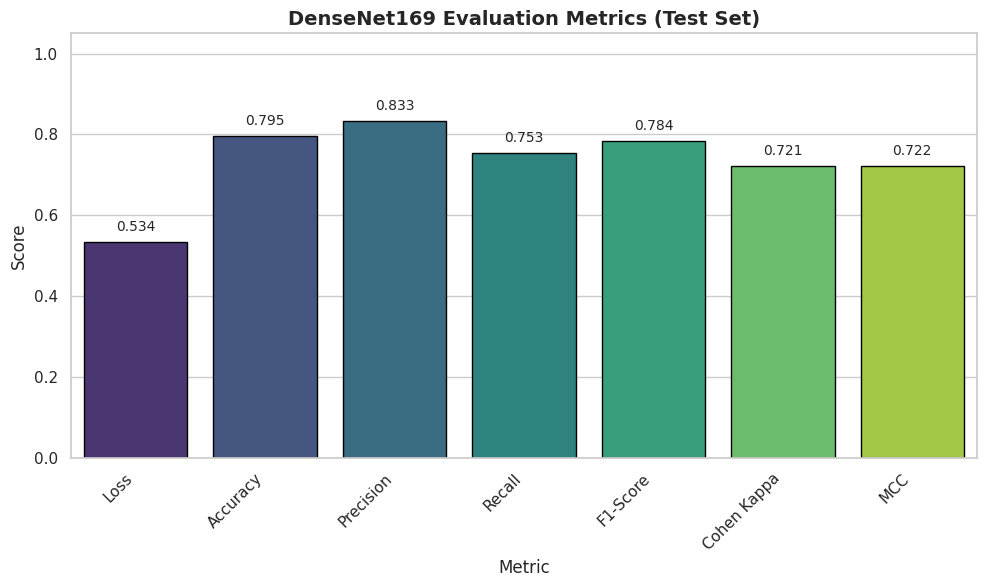

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=metric_names, y=metric_values, palette='viridis', edgecolor='black')

plt.title('DenseNet169 Evaluation Metrics (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.ylim(0, 1.05) # Metrics like accuracy, precision, recall, F1 are usually between 0 and 1
plt.xticks(rotation=45, ha='right')

for index, value in enumerate(metric_values):
    plt.text(index, value + 0.02, f'{value:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('densenet_metrics_bar_chart.png', bbox_inches='tight')
plt.show()

#### **Fine Tuned DenseNet169**

In [ ]:
def build_densenet_finetuned(num_classes, input_shape=(128, 128, 3)):
    base = DenseNet169(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )

    # Freeze all layers
    for layer in base.layers:
        layer.trainable = False

    # Fine-tune approximately the last 80 layers
    for layer in base.layers[-80:]:
        if not isinstance(layer, BatchNormalization):
            layer.trainable = True

    x = GlobalAveragePooling2D()(base.output)

    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(
        inputs=base.input,
        outputs=outputs,
        name="DenseNet169_FineTuned"
    )

    return model

In [ ]:
densenet_finetuned_model = build_densenet_finetuned(NUM_CLASSES)

densenet_finetuned_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        'precision',
        'recall',
        F1Score(average='macro')
    ]
)

51877672/51877672 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print("\n--- Starting Fine-tuned DenseNet169 Training ---")
densenet_finetuned_history = densenet_finetuned_model.fit(
    train_gen, epochs=EPOCHS,
    validation_data=val_gen,
    class_weight=class_weights_dict,
    callbacks=get_callbacks('densenet_finetuned'), verbose=1
)
print("--- Fine-tuned DenseNet169 Training Complete ---")


--- Starting Fine-tuned DenseNet169 Training ---
Epoch 1/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 0.3037 - f1_score: 0.3000 - loss: 1.9969 - precision: 0.3114 - recall: 0.2306
Epoch 1: val_accuracy improved from None to 0.44139, saving model to best_densenet_finetuned.keras

Epoch 1: finished saving model to best_densenet_finetuned.keras
530/530 ━━━━━━━━━━━━━━━━━━━━ 411s 664ms/step - accuracy: 0.3421 - f1_score: 0.3384 - loss: 1.8470 - precision: 0.3579 - recall: 0.2670 - val_accuracy: 0.4414 - val_f1_score: 0.4294 - val_loss: 1.3326 - val_precision: 0.4995 - val_recall: 0.3324 - learning_rate: 1.0000e-05
Epoch 2/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 0s 516ms/step - accuracy: 0.4295 - f1_score: 0.4231 - loss: 1.5540 - precision: 0.4605 - recall: 0.3571
Epoch 2: val_accuracy improved from 0.44139 to 0.57638, saving model to best_densenet_finetuned.keras

Epoch 2: finished saving model to best_densenet_finetuned.keras
530/530 ━━━━━━━━━━━━━━━━━━━━ 290s 546ms/step - accuracy: 0

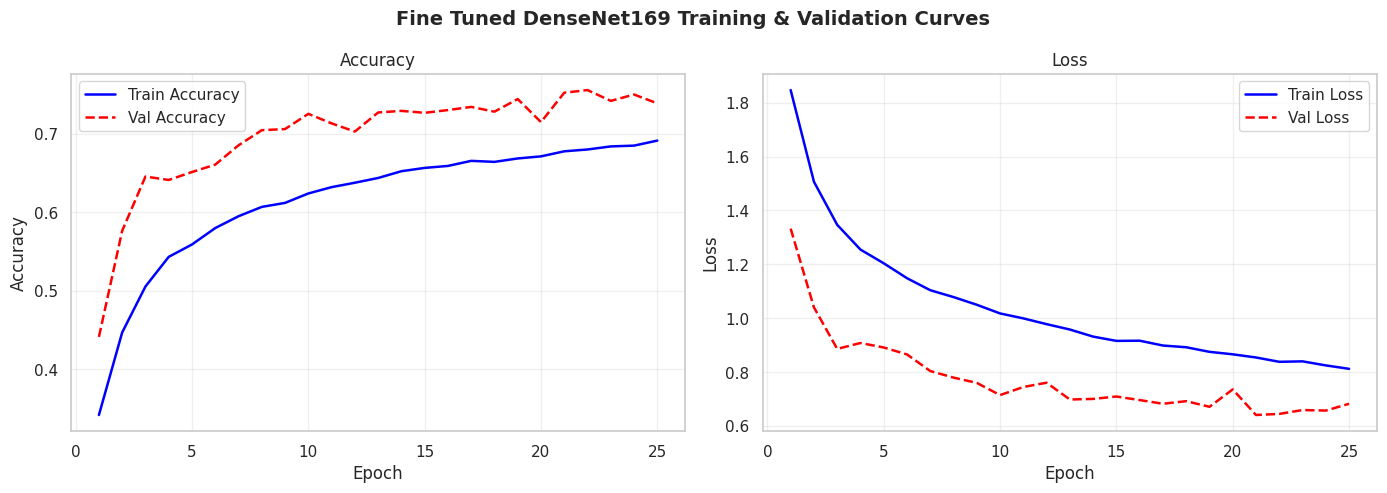

In [ ]:
# Plotting accuracy and loss curves for Fine Tuned DenseNet model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Fine Tuned DenseNet169 Training & Validation Curves", fontsize=14, fontweight='bold')

hist = densenet_finetuned_history.history
epochs_ran = range(1, len(hist['accuracy']) + 1)

# Plot Training and Validation Accuracy
axes[0].plot(epochs_ran, hist['accuracy'], label='Train Accuracy', color='blue', linewidth=1.8)
axes[0].plot(epochs_ran, hist['val_accuracy'], label='Val Accuracy', color='red', linestyle='--', linewidth=1.8)
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot Training and Validation Loss
axes[1].plot(epochs_ran, hist['loss'], label='Train Loss', color='blue', linewidth=1.8)
axes[1].plot(epochs_ran, hist['val_loss'], label='Val Loss', color='red', linestyle='--', linewidth=1.8)
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("densenet_finetuned_training_curves.png", bbox_inches='tight')
plt.show()


In [ ]:
densenet_finetuned_history_dict = densenet_finetuned_history.history
for key, value_list in densenet_finetuned_history_dict.items():
    densenet_finetuned_history_dict[key] = [float(val) for val in value_list]

In [ ]:
with open('densenet_finetuned_history.json', 'w') as f:
    json.dump(densenet_finetuned_history_dict, f, indent=4)
print("Fine Tuned DenseNet training history saved to densenet_finetuned_history.json")

Fine Tuned DenseNet training history saved to densenet_finetuned_history.json


In [ ]:
print("  Calculating evaluation metrics for Fine Tuned DenseNet...")
densenet_finetuned_eval_metrics = full_evaluate(densenet_finetuned_model, 'Fine Tuned DenseNet', test_gen, CLASS_NAMES)

json_friendly_densenet_finetuned_metrics = densenet_finetuned_eval_metrics.copy()

  Calculating evaluation metrics for Fine Tuned DenseNet...


In [ ]:
json_serializable_densenet_finetuned_metrics = densenet_finetuned_eval_metrics.copy()

for key, value in json_serializable_densenet_finetuned_metrics.items():
    if isinstance(value, np.ndarray):
        json_serializable_densenet_finetuned_metrics[key] = value.tolist()
    elif isinstance(value, (np.float32, np.float64, np.int64)):
        json_serializable_densenet_finetuned_metrics[key] = float(value)

In [ ]:
json_filename = 'densenet_finetuned_model_metrics.json'
with open(json_filename, 'w') as f:
    json.dump(json_serializable_densenet_finetuned_metrics, f, indent=4)
print(f"\nFine Tuned DenseNet evaluation metrics saved to {json_filename}")

In [ ]:
densenet_finetuned_metrics_df = pd.DataFrame([json_friendly_densenet_finetuned_metrics])
# densenet_finetuned_metrics_df

In [ ]:
metrics_to_plot = densenet_finetuned_metrics_df.drop(columns=['Model'], errors='ignore')
metrics_to_plot = metrics_to_plot.loc[:, ~metrics_to_plot.columns.str.startswith('_')]

metric_names = metrics_to_plot.columns.tolist()
metric_values = metrics_to_plot.iloc[0].tolist()

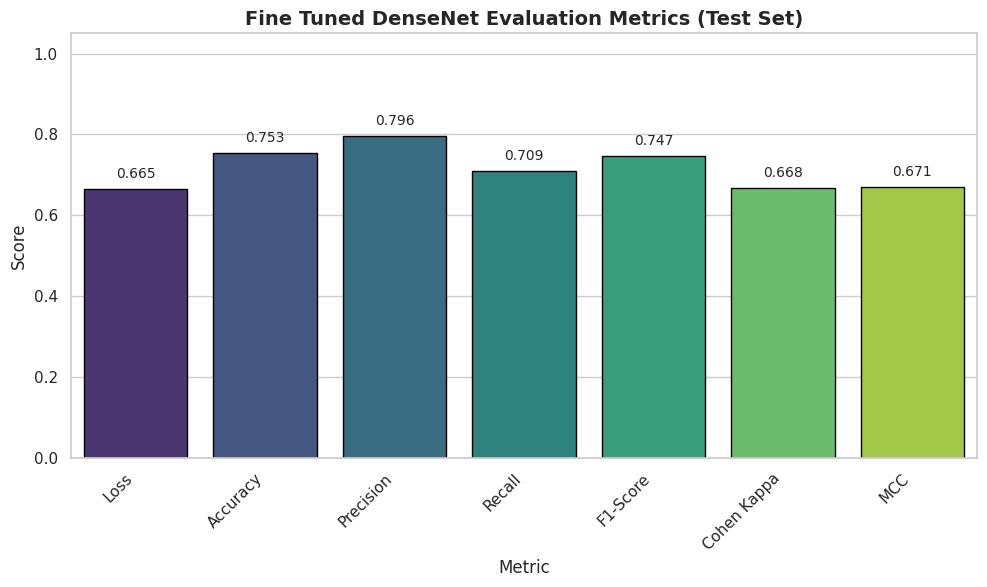

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=metric_names, y=metric_values, palette='viridis', edgecolor='black')

plt.title('Fine Tuned DenseNet Evaluation Metrics (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.ylim(0, 1.05) # Metrics like accuracy, precision, recall, F1 are usually between 0 and 1
plt.xticks(rotation=45, ha='right')

for index, value in enumerate(metric_values):
    plt.text(index, value + 0.02, f'{value:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('densenet_finetuned_metrics_bar_chart.png', bbox_inches='tight')
plt.show()

#### **Vision Transformers**

In [31]:
PATCH_SIZE     = 16
NUM_PATCHES    = (IMAGE_SIZE[0] // PATCH_SIZE) ** 2
PROJ_DIM       = 128
NUM_HEADS      = 8
TRANSFORMER_L  = 6
MLP_UNITS      = [512, 256]

In [32]:
class Patches(layers.Layer):
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID"
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [tf.shape(images)[0], -1, patch_dims])
        return patches

In [33]:
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches   = num_patches
        self.projection    = layers.Dense(projection_dim)
        self.pos_embedding = layers.Embedding(num_patches, projection_dim)

    def call(self, patch):
        positions = tf.range(0, self.num_patches, delta=1)
        return self.projection(patch) + self.pos_embedding(positions)

In [34]:
def build_vit(num_classes, input_shape=(128, 128, 3)):
    inputs = layers.Input(shape=input_shape)
    patches = Patches(PATCH_SIZE)(inputs)
    encoded = PatchEncoder(NUM_PATCHES, PROJ_DIM)(patches)

    for _ in range(TRANSFORMER_L):
        x1  = LayerNormalization(epsilon=1e-6)(encoded)
        att = MultiHeadAttention(num_heads=NUM_HEADS, key_dim=PROJ_DIM, dropout=0.1)(x1, x1)
        x2  = Add()([att, encoded])
        x3  = LayerNormalization(epsilon=1e-6)(x2)
        x3  = layers.Dense(PROJ_DIM * 2, activation='gelu')(x3)
        x3  = layers.Dropout(0.1)(x3)
        x3  = layers.Dense(PROJ_DIM, activation='gelu')(x3)
        x3  = layers.Dropout(0.1)(x3)
        encoded = Add()([x3, x2])

    rep = LayerNormalization(epsilon=1e-6)(encoded)
    rep = layers.GlobalAveragePooling1D()(rep)
    rep = layers.Dropout(0.4)(rep)
    for units in MLP_UNITS:
        rep = layers.Dense(units, activation='gelu')(rep)
        rep = layers.Dropout(0.3)(rep)
    out = layers.Dense(num_classes, activation='softmax')(rep)
    return Model(inputs=inputs, outputs=out, name='ViT')

In [35]:
vit_model = build_vit(NUM_CLASSES)
vit_model.compile(
    optimizer=optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall', F1Score(average='macro')]
)
# vit_model.summary()

In [36]:
vit_history = vit_model.fit(
    train_gen, epochs=EPOCHS,
    validation_data=val_gen,
    class_weight=class_weights_dict,
    callbacks=get_callbacks('vit'), verbose=1
)

Epoch 1/25
529/529 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.3326 - f1_score: 0.3287 - loss: 1.3287 - precision: 0.3979 - recall: 0.0532
Epoch 1: val_accuracy improved from None to 0.51477, saving model to best_vit.keras

Epoch 1: finished saving model to best_vit.keras
529/529 ━━━━━━━━━━━━━━━━━━━━ 297s 482ms/step - accuracy: 0.3707 - f1_score: 0.3679 - loss: 1.2737 - precision: 0.4524 - recall: 0.0869 - val_accuracy: 0.5148 - val_f1_score: 0.4893 - val_loss: 1.0821 - val_precision: 0.6119 - val_recall: 0.3036 - learning_rate: 1.0000e-04
Epoch 2/25
529/529 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.4518 - f1_score: 0.4472 - loss: 1.1698 - precision: 0.5242 - recall: 0.2117
Epoch 2: val_accuracy did not improve from 0.51477
529/529 ━━━━━━━━━━━━━━━━━━━━ 229s 433ms/step - accuracy: 0.4652 - f1_score: 0.4607 - loss: 1.1486 - precision: 0.5382 - recall: 0.2336 - val_accuracy: 0.4994 - val_f1_score: 0.4960 - val_loss: 1.0938 - val_precision: 0.5568 - val_recall: 0.3193 - learnin

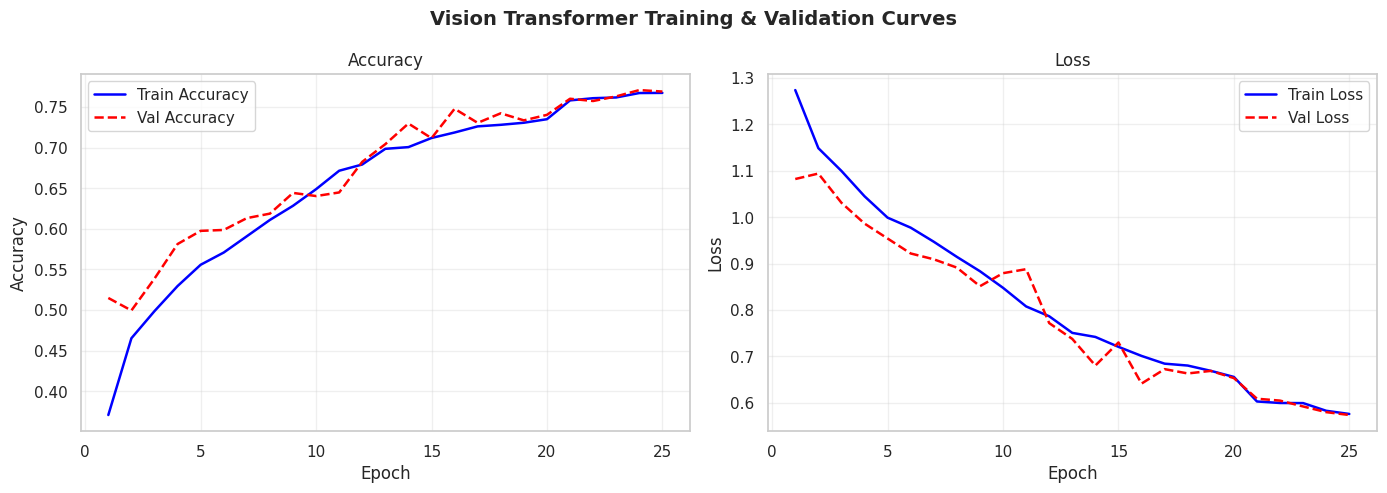

In [37]:
# Plotting accuracy and loss curves for Vision Transformer model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Vision Transformer Training & Validation Curves", fontsize=14, fontweight='bold')

hist = vit_history.history
epochs_ran = range(1, len(hist['accuracy']) + 1)

# Plot Training and Validation Accuracy
axes[0].plot(epochs_ran, hist['accuracy'], label='Train Accuracy', color='blue', linewidth=1.8)
axes[0].plot(epochs_ran, hist['val_accuracy'], label='Val Accuracy', color='red', linestyle='--', linewidth=1.8)
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot Training and Validation Loss
axes[1].plot(epochs_ran, hist['loss'], label='Train Loss', color='blue', linewidth=1.8)
axes[1].plot(epochs_ran, hist['val_loss'], label='Val Loss', color='red', linestyle='--', linewidth=1.8)
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("vit_training_curves.png", bbox_inches='tight')
plt.show()

In [38]:
vit_history_dict = vit_history.history
for key, value_list in vit_history_dict.items():
    vit_history_dict[key] = [float(val) for val in value_list]

In [39]:
with open('vit_history.json', 'w') as f:
    json.dump(vit_history_dict, f, indent=4)
print("Vision Transformer training history saved to vit_history.json")

Vision Transformer training history saved to vit_history.json


In [40]:
print("  Calculating evaluation metrics for Vision Transformer...")
vit_eval_metrics = full_evaluate(vit_model, 'Vision Transformer', test_gen, CLASS_NAMES)

json_friendly_vit_metrics = vit_eval_metrics.copy()

  Calculating evaluation metrics for Vision Transformer...


In [41]:
json_serializable_vit_metrics = json_friendly_vit_metrics.copy()

for key, value in json_serializable_vit_metrics.items():
    if isinstance(value, np.ndarray):
        json_serializable_vit_metrics[key] = value.tolist()
    elif isinstance(value, (np.float32, np.float64, np.int64)):
        json_serializable_vit_metrics[key] = float(value)

In [42]:
json_filename = 'vit_model_metrics.json'
with open(json_filename, 'w') as f:
    json.dump(json_serializable_vit_metrics, f, indent=4)
print(f"\nVision Transformer evaluation metrics saved to {json_filename}")


Vision Transformer evaluation metrics saved to vit_model_metrics.json


In [43]:
vit_metrics_df = pd.DataFrame([json_friendly_vit_metrics])
vit_metrics_df

,Model,Loss,Accuracy,Precision,Recall,F1-Score,Cohen Kappa,MCC,_preds,_pred_labels,_true_labels
0,Vision Transformer,0.5115,0.8027,0.8456,0.7614,0.7995,0.733,0.7343,"[[0.8381616, 0.022447562, 0.0081862295, 0.1312...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [44]:
metrics_to_plot = vit_metrics_df.drop(columns=['Model'], errors='ignore')
metrics_to_plot = metrics_to_plot.loc[:, ~metrics_to_plot.columns.str.startswith('_')]

metric_names = metrics_to_plot.columns.tolist()
metric_values = metrics_to_plot.iloc[0].tolist()

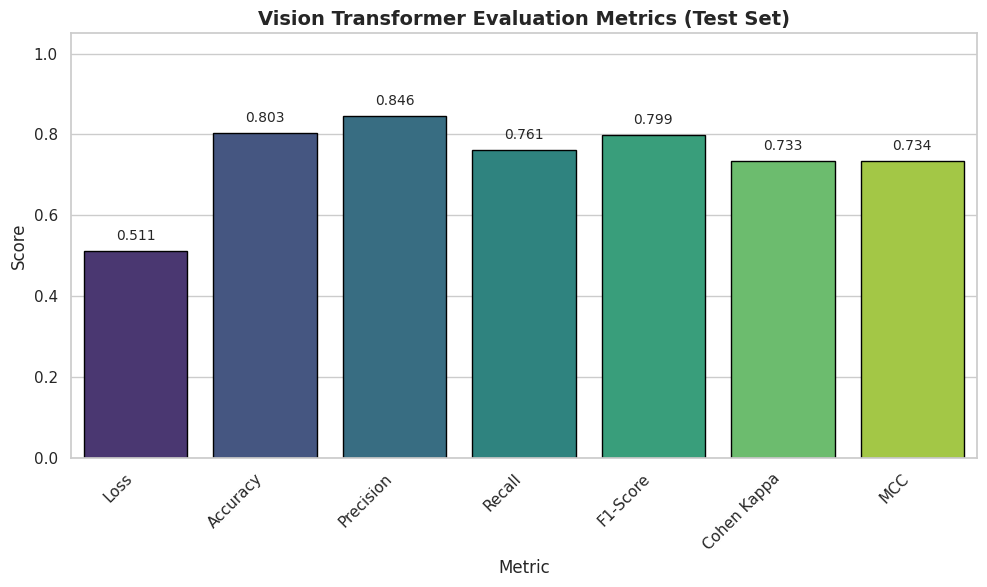

In [45]:
plt.figure(figsize=(10, 6))
sns.barplot(x=metric_names, y=metric_values, palette='viridis', edgecolor='black')

plt.title('Vision Transformer Evaluation Metrics (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.ylim(0, 1.05) # Metrics like accuracy, precision, recall, F1 are usually between 0 and 1
plt.xticks(rotation=45, ha='right')

for index, value in enumerate(metric_values):
    plt.text(index, value + 0.02, f'{value:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('vit_metrics_bar_chart.png', bbox_inches='tight')
plt.show()

## **Evaluation on Test Set**

In [46]:
# List of JSON files containing evaluation metrics
json_files = [
    'cnn_model_metrics.json',
    'densenet_model_metrics.json',
    'densenet_finetuned_model_metrics.json',
    'vit_model_metrics.json'
]

all_metrics_list = []

# Load metrics from each JSON file
for file_path in json_files:
    try:
        with open(file_path, 'r') as f:
            metrics = json.load(f)
            all_metrics_list.append(metrics)
    except FileNotFoundError:
        print(f"Warning: {file_path} not found. Skipping.")

# Create a pandas DataFrame from the combined metrics
metrics_df = pd.DataFrame(all_metrics_list)

metrics_df

,Model,Loss,Accuracy,Precision,Recall,F1-Score,Cohen Kappa,MCC,_preds,_pred_labels,_true_labels
0,Custom CNN,1.1857,0.6403,0.6552,0.6218,0.5877,0.5132,0.5408,"[[0.027045799419283867, 0.23074078559875488, 0...","[2, 2, 2, 1, 1, 2, 1, 1, 0, 1, 1, 1, 2, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,DenseNet169,0.5336,0.7948,0.8327,0.7535,0.7840,0.7206,0.7218,"[[0.989243745803833, 0.010666783899068832, 1.2...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,Fine Tuned DenseNet,0.6653,0.7530,0.7957,0.7093,0.7471,0.6683,0.6707,"[[0.23048022389411926, 0.544489324092865, 0.14...","[1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,Vision Transformer,0.5115,0.8027,0.8456,0.7614,0.7995,0.7330,0.7343,"[[0.8381615877151489, 0.022447561845183372, 0....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


#### **Metric Comparison Bar Chart**

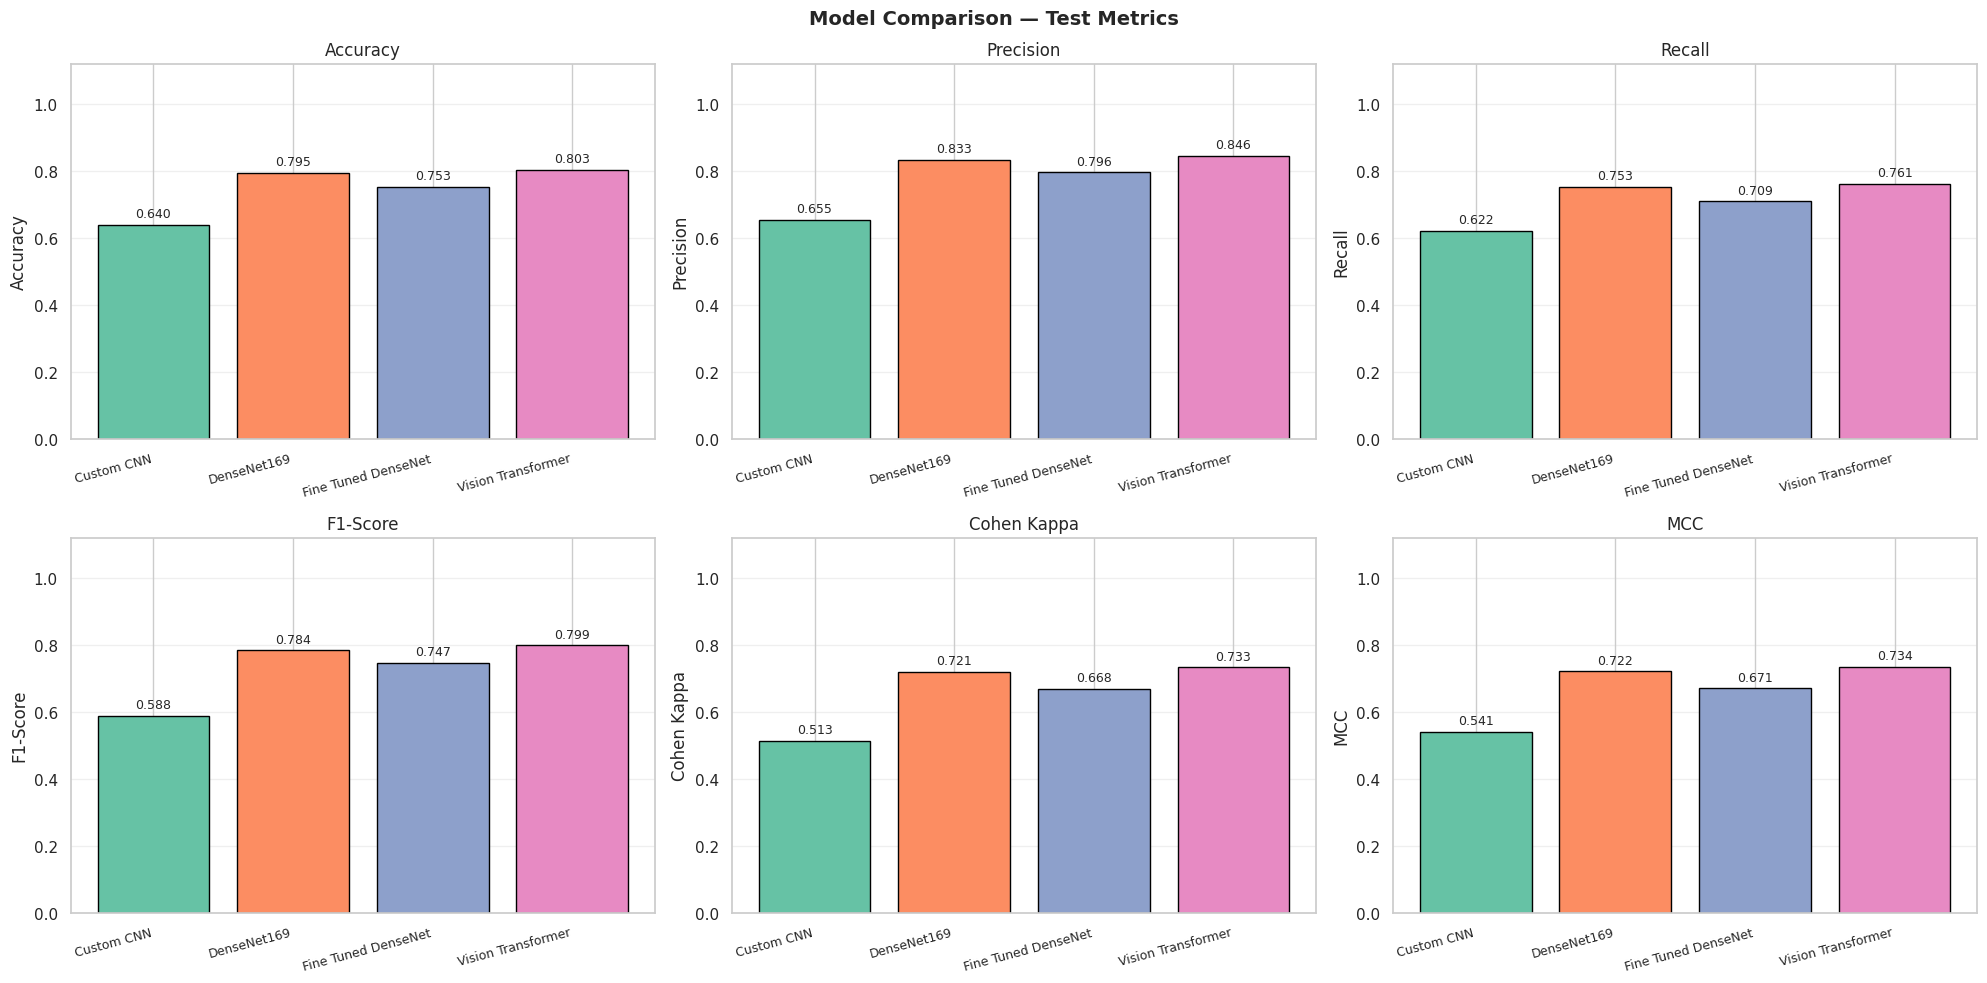

In [47]:
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Cohen Kappa', 'MCC']

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle("Model Comparison — Test Metrics", fontsize=14, fontweight='bold')

pal = sns.color_palette("Set2", len(metrics_df))

for ax, metric in zip(axes.flat, metric_cols):
    bars = ax.bar(metrics_df['Model'], metrics_df[metric], color=pal, edgecolor='black')
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
    ax.set_title(metric, fontsize=12)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.12)
    ax.set_xticklabels(metrics_df['Model'], rotation=15, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("eval_metric_comparison.png", bbox_inches='tight')
plt.show()

#### **Radar Chart**

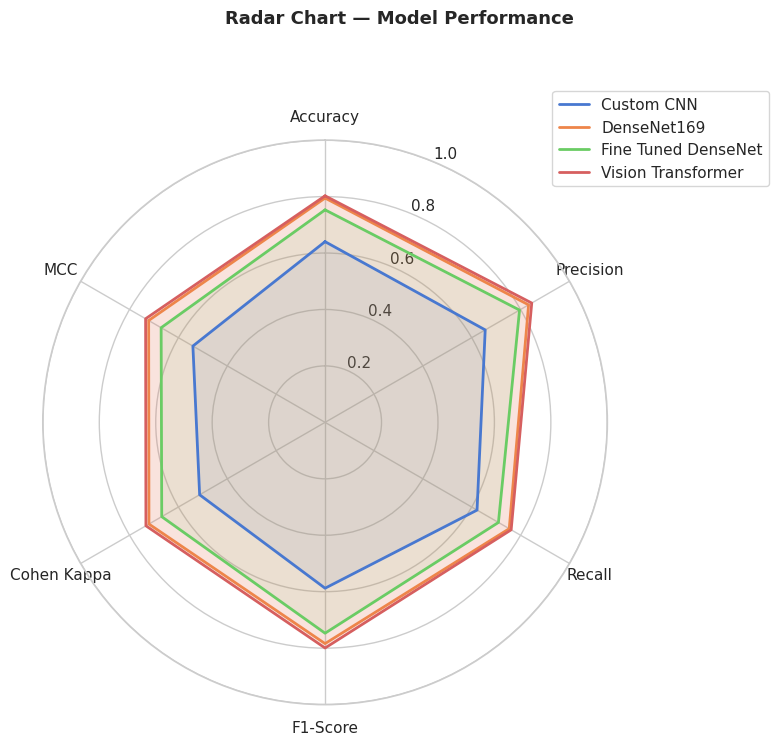

In [48]:
radar_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Cohen Kappa', 'MCC']
N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.suptitle("Radar Chart — Model Performance", fontsize=13, fontweight='bold')

for i, row in metrics_df.iterrows():
    values = [max(0, row[m]) for m in radar_metrics]
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row['Model'])
    ax.fill(angles, values, alpha=0.1)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), radar_metrics)
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig("eval_radar_chart.png", bbox_inches='tight')
plt.show()

#### **Confusion Matrices**

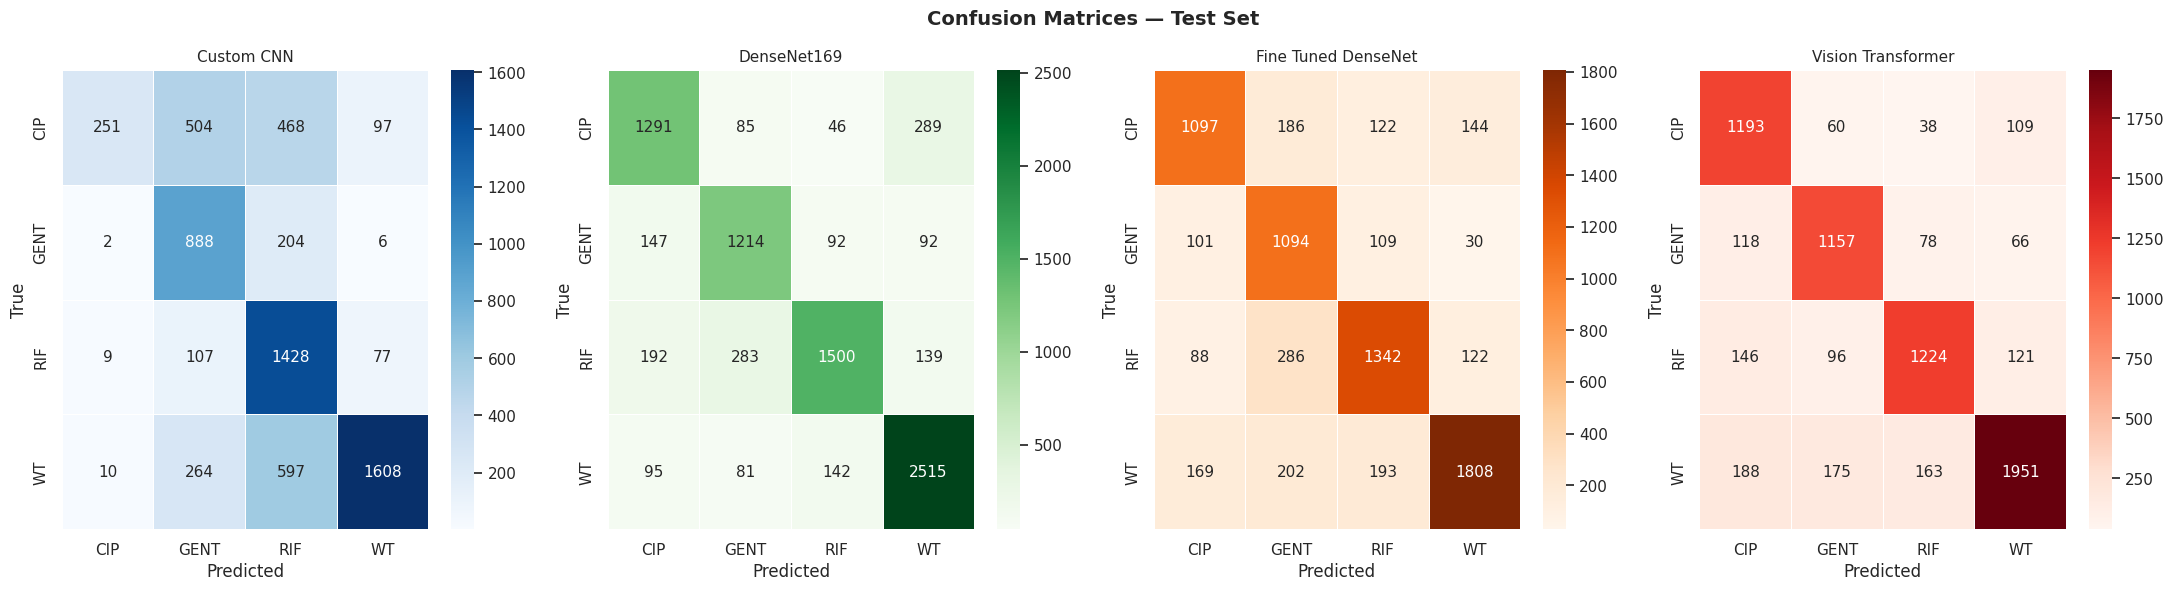

In [49]:
# Create a dictionary similar to model_registry from metrics_df
eval_results_df = metrics_df[['Model', '_true_labels', '_pred_labels', '_preds']]

fig, axes = plt.subplots(1, len(eval_results_df), figsize=(22, 6))
fig.suptitle("Confusion Matrices — Test Set", fontsize=14, fontweight='bold')
cmaps_list = ['Blues', 'Greens', 'Oranges', 'Reds']

for ax, (idx, row), cmap in zip(axes, eval_results_df.iterrows(), cmaps_list):
    model_name = row['Model']
    true_labels = row['_true_labels']
    pred_labels = row['_pred_labels']

    cm = confusion_matrix(true_labels, pred_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax, cbar=True,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=0.5)
    ax.set_title(model_name, fontsize=11)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.savefig("eval_confusion_matrices.png", bbox_inches='tight')
plt.show()

#### **Normalised Confusion Matrices**

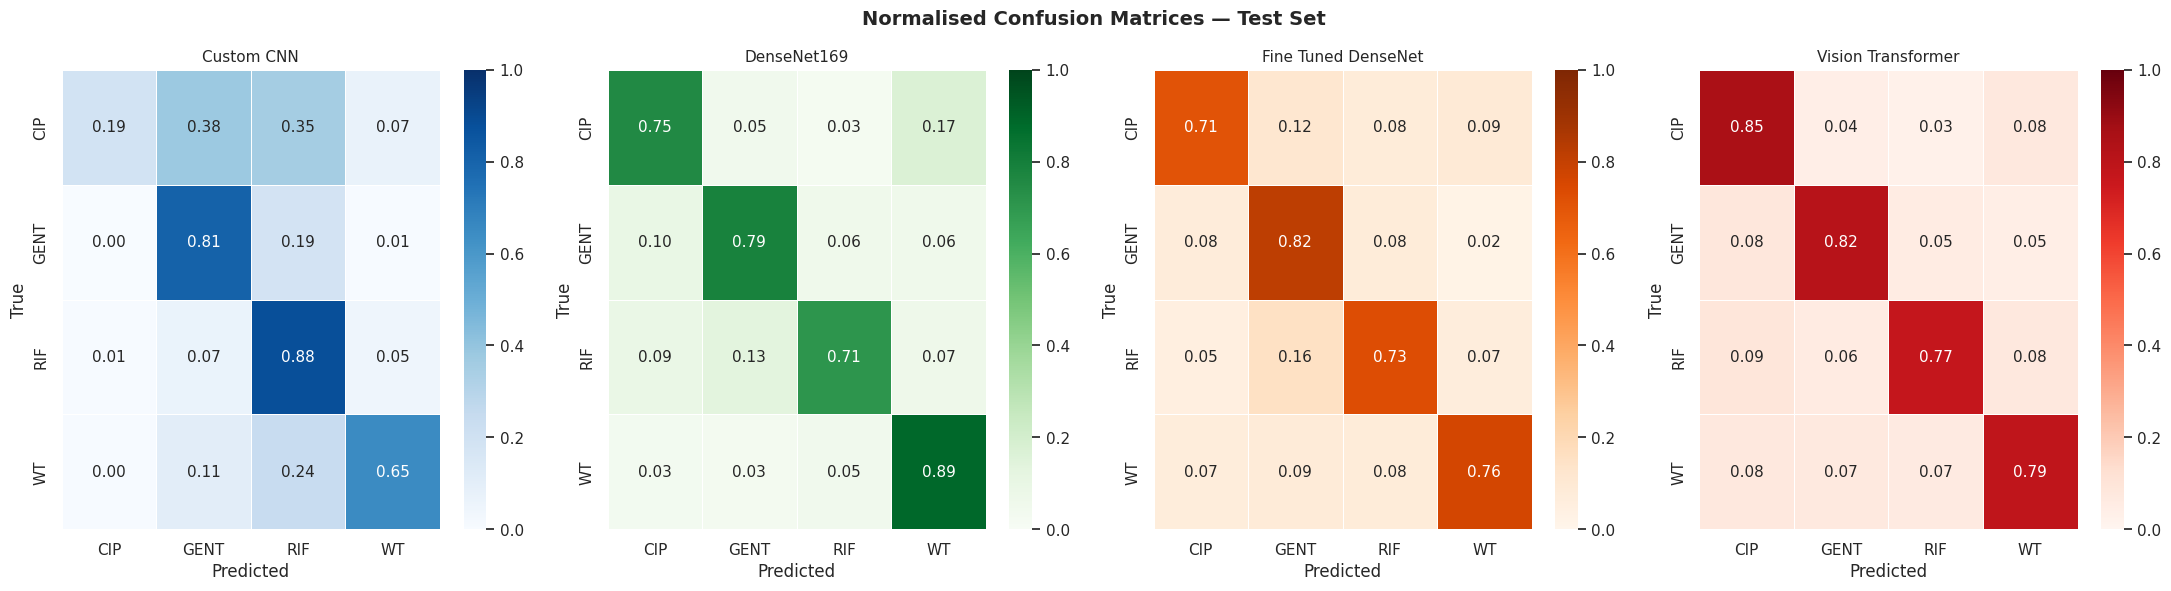

In [50]:
fig, axes = plt.subplots(1, len(eval_results_df), figsize=(22, 6))
fig.suptitle("Normalised Confusion Matrices — Test Set", fontsize=14, fontweight='bold')
cmaps_list = ['Blues', 'Greens', 'Oranges', 'Reds']

for ax, (idx, row), cmap in zip(axes, eval_results_df.iterrows(), cmaps_list):
    model_name = row['Model']
    true_labels = row['_true_labels']
    pred_labels = row['_pred_labels']

    cm = confusion_matrix(true_labels, pred_labels)
    # Normalize the confusion matrix by row (true labels)
    cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap=cmap, ax=ax, cbar=True,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=0.5, vmin=0, vmax=1)
    ax.set_title(model_name, fontsize=11)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.savefig("eval_normalised_confusion_matrices.png", bbox_inches='tight')
plt.show()

#### **Per-Class Precision / Recall / F1**

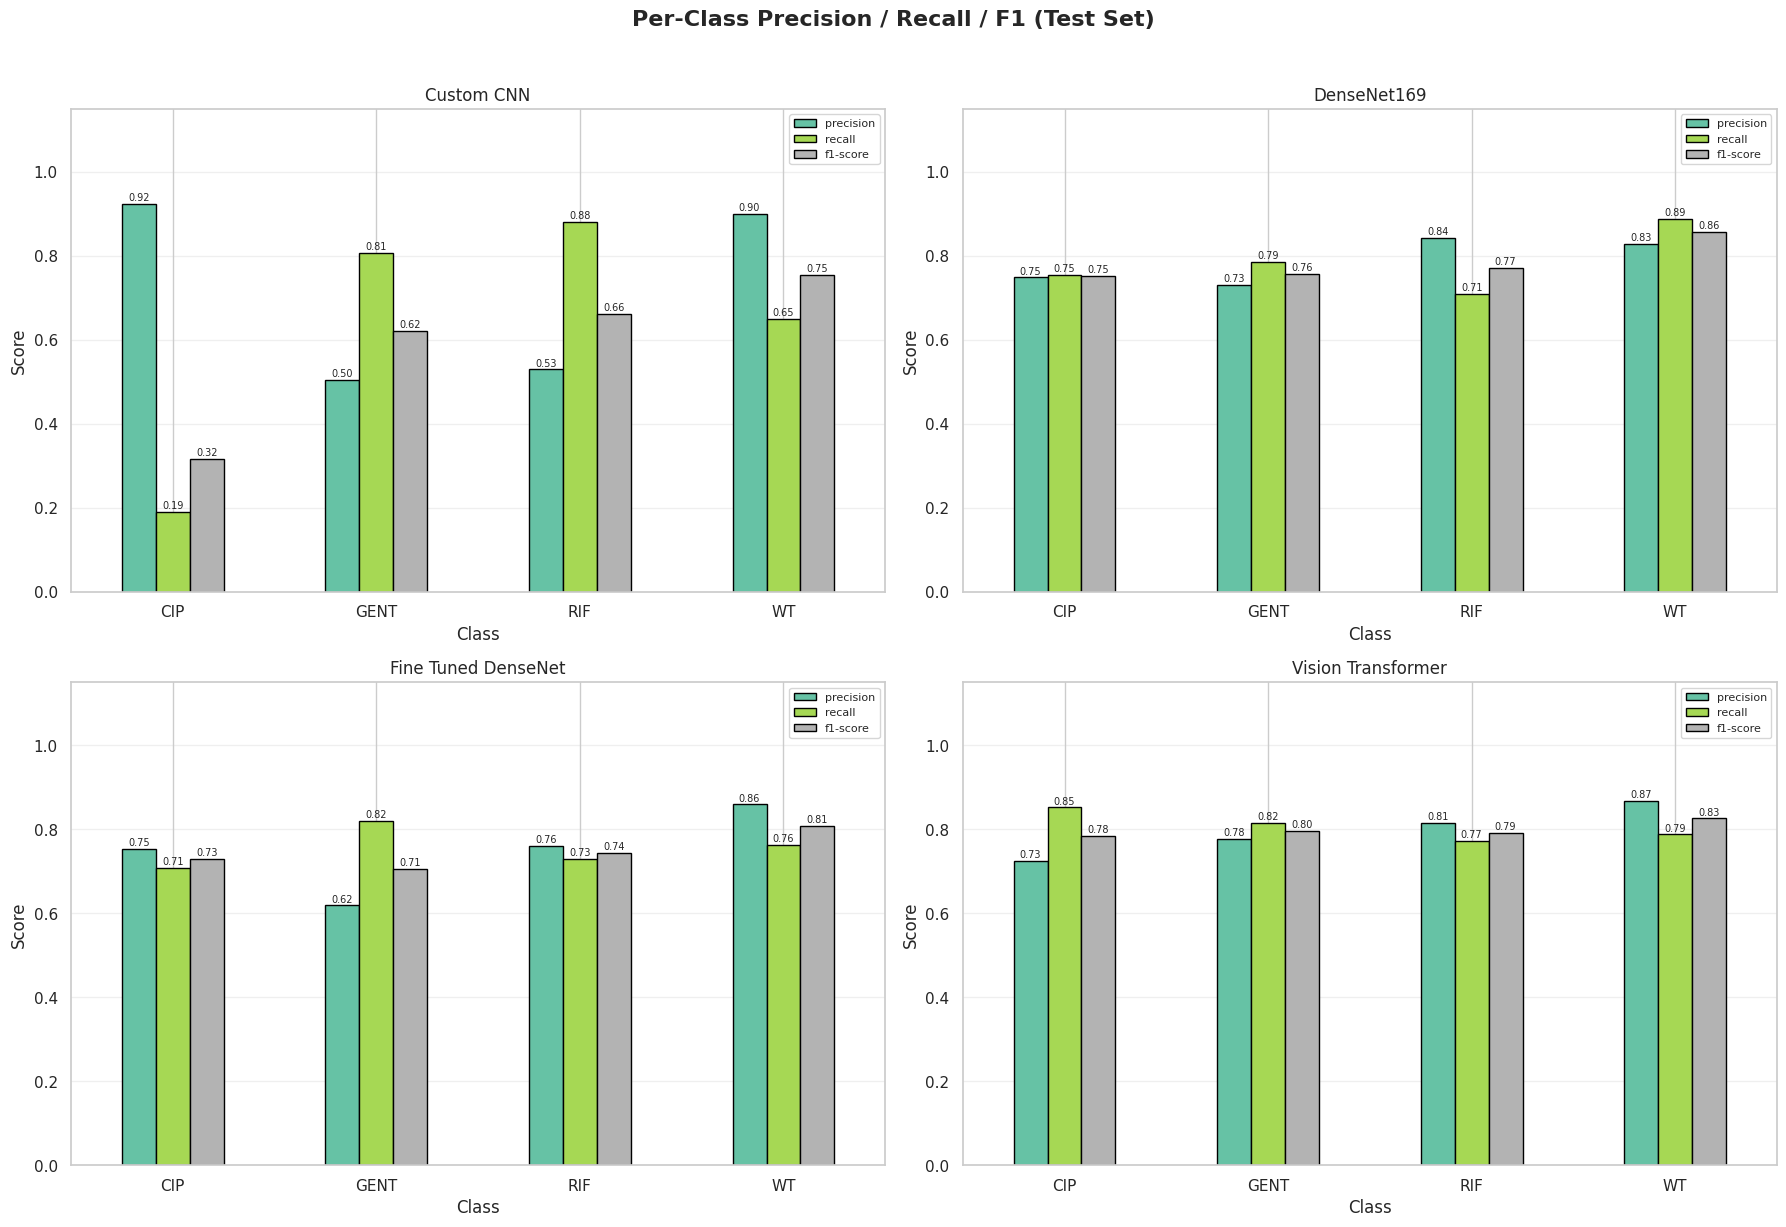

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Per-Class Precision / Recall / F1 (Test Set)", fontsize=16, fontweight='bold', y=1.02)

axes_flat = axes.flatten()

for i, (idx, row) in enumerate(eval_results_df.iterrows()):
    ax = axes_flat[i]
    model_name = row['Model']
    true_labels = row['_true_labels']
    pred_labels = row['_pred_labels']

    report = classification_report(
        true_labels, pred_labels,
        target_names=CLASS_NAMES, output_dict=True, zero_division=0
    )

    # Extract precision, recall, f1-score for each class
    per_class_metrics = pd.DataFrame({
        cls: { 'precision': report[cls]['precision'], 'recall': report[cls]['recall'], 'f1-score': report[cls]['f1-score'] }
        for cls in CLASS_NAMES
    }).T

    per_class_metrics.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black')
    ax.set_title(model_name, fontsize=12)
    ax.set_xlabel("Class")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.15)
    ax.set_xticklabels(CLASS_NAMES, rotation=0)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=1, fontsize=7)

plt.tight_layout()
plt.savefig("eval_per_class_metrics_2x2.png", bbox_inches='tight')
plt.show()

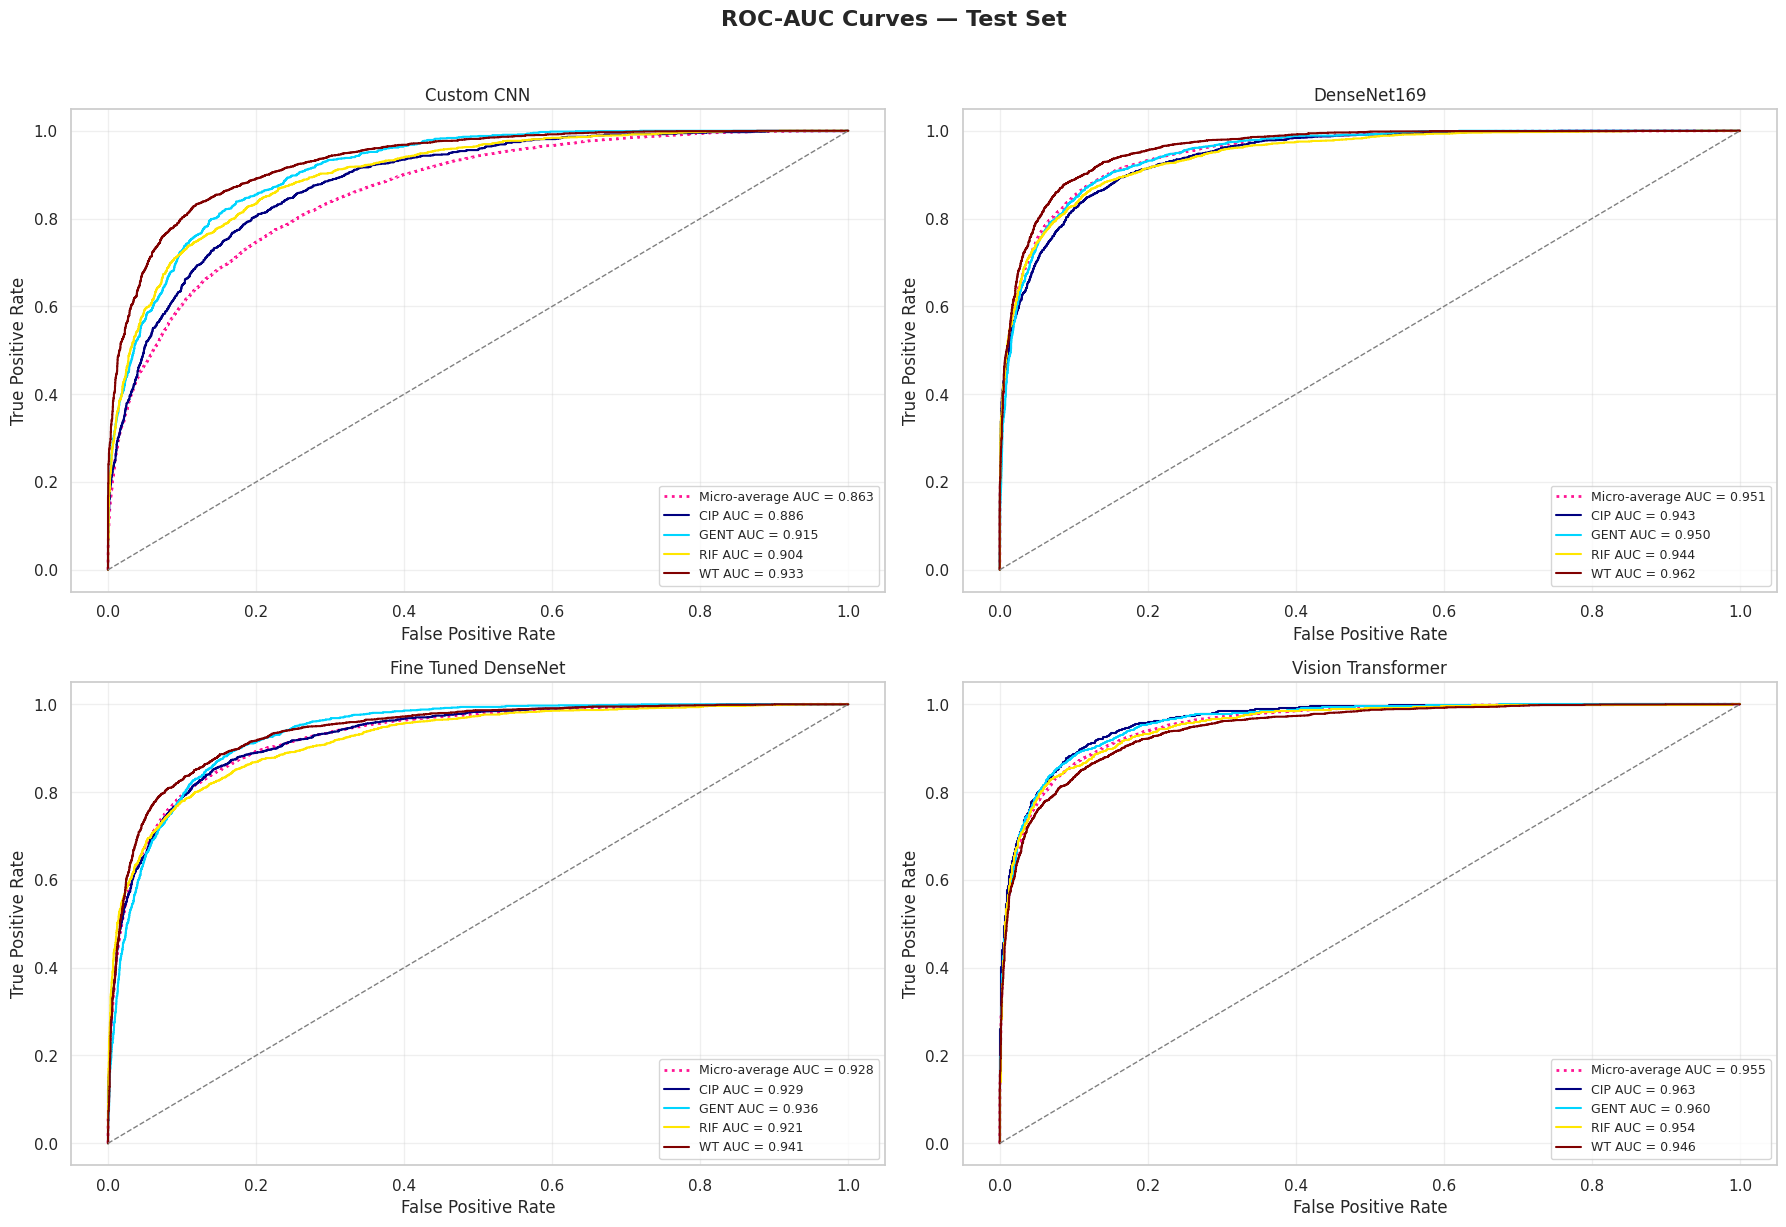

In [52]:
test_gen.reset()
lb = LabelBinarizer()
lb.fit(test_gen.classes)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("ROC-AUC Curves — Test Set", fontsize=16, fontweight='bold', y=1.02)

axes_flat = axes.flatten()

for i, (idx, row) in enumerate(eval_results_df.iterrows()):
    ax = axes_flat[i]
    model_name = row['Model']
    true_labels_encoded = lb.transform(row['_true_labels'])
    preds = np.array(row['_preds'])

    # Micro-average ROC curve
    fpr_micro, tpr_micro, _ = roc_curve(true_labels_encoded.ravel(), preds.ravel())
    auc_micro = auc(fpr_micro, tpr_micro)
    ax.plot(fpr_micro, tpr_micro, label=f'Micro-average AUC = {auc_micro:.3f}',
            color='deeppink', linestyle=':', linewidth=2)

    # Per-class ROC curves
    colors = plt.cm.get_cmap('jet', len(CLASS_NAMES))
    for j, class_name in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(true_labels_encoded[:, j], preds[:, j])
        class_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{class_name} AUC = {class_auc:.3f}',
                color=colors(j), linewidth=1.5)

    ax.plot([0, 1], [0, 1], 'k--', lw=1, color='gray') # Random guess line
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(model_name, fontsize=12)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("eval_roc_auc_curves_2x2.png", bbox_inches='tight')
plt.show()

## **Test Set Evaluation using Best Model**

In [54]:
best_row = metrics_df.loc[metrics_df['F1-Score'].idxmax()]
best_name = best_row['Model']

# Map model names to their saved filenames
model_name_to_filename = {
    'Custom CNN': 'best_cnn.keras',
    'DenseNet169': 'best_densenet.keras',
    'Fine Tuned DenseNet': 'best_densenet_finetuned.keras',
    'Vision Transformer': 'best_vit.keras'
}

# Custom objects for Vision Transformer model
custom_objects = {
    'Patches': Patches,
    'PatchEncoder': PatchEncoder
}

# Load the best model
if best_name in model_name_to_filename:
    model_filename = model_name_to_filename[best_name]
    # Pass custom_objects when loading models that use custom layers
    if best_name == 'Vision Transformer':
        best_model = tf.keras.models.load_model(model_filename, custom_objects=custom_objects)
    else:
        best_model = tf.keras.models.load_model(model_filename)
    print(f"Loaded best model: {best_name} from {model_filename}\n")
else:
    print(f"Warning: Model file not found for {best_name}. Cannot load best_model.\n")
    best_model = None # Handle case where model is not found

print(f"Best Model (by Test F1): {best_name}  (F1 = {best_row['F1-Score']:.4f})")

Loaded best model: Vision Transformer from best_vit.keras

Best Model (by Test F1): Vision Transformer  (F1 = 0.7995)


In [56]:
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 64

val_test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = val_test_datagen.flow_from_directory(
    'segmented images/test_segmented',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Evaluate on test set
test_gen.reset()
test_result = full_evaluate(best_model, best_name, test_gen, CLASS_NAMES)

print(f"Test Set Results — {best_name}:")
for k, v in test_result.items():
    if not k.startswith('_'):
        print(f"  {k:>15s}: {v}")

Found 6883 images belonging to 4 classes.
Test Set Results — Vision Transformer:
            Model: Vision Transformer
             Loss: 0.5082
         Accuracy: 0.8087
        Precision: 0.8417
           Recall: 0.7693
         F1-Score: 0.8063
      Cohen Kappa: 0.7416
              MCC: 0.7434


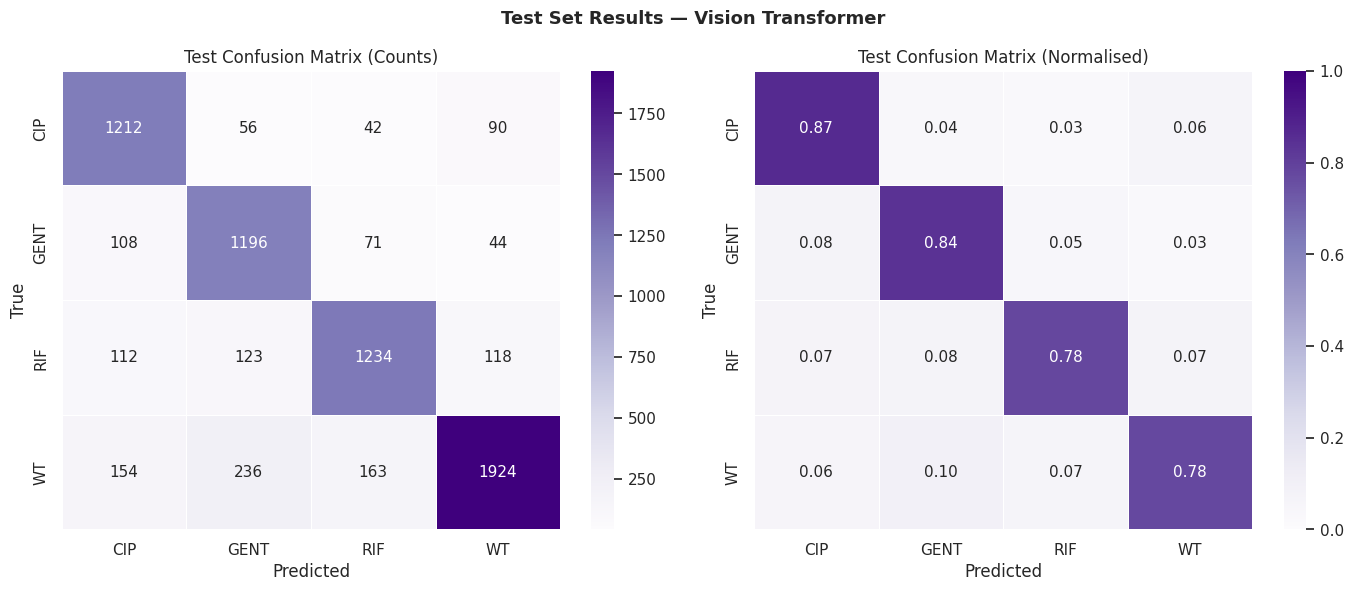

In [57]:
# Test Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"Test Set Results — {best_name}", fontsize=13, fontweight='bold')

cm_test   = confusion_matrix(test_result['_true_labels'], test_result['_pred_labels'])
cm_test_n = cm_test.astype('float') / cm_test.sum(axis=1, keepdims=True)

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=0.5)
axes[0].set_title("Test Confusion Matrix (Counts)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

sns.heatmap(cm_test_n, annot=True, fmt='.2f', cmap='Purples', ax=axes[1],
            vmin=0, vmax=1, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=0.5)
axes[1].set_title("Test Confusion Matrix (Normalised)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

plt.tight_layout()
plt.savefig("test_confusion_matrix.png", bbox_inches='tight')
plt.show()

In [58]:
print(f"Test Classification Report — {best_name}:")
print(classification_report(
    test_result['_true_labels'], test_result['_pred_labels'],
    target_names=CLASS_NAMES, zero_division=0
))

Test Classification Report — Vision Transformer:
              precision    recall  f1-score   support

         CIP       0.76      0.87      0.81      1400
        GENT       0.74      0.84      0.79      1419
         RIF       0.82      0.78      0.80      1587
          WT       0.88      0.78      0.83      2477

    accuracy                           0.81      6883
   macro avg       0.80      0.82      0.81      6883
weighted avg       0.82      0.81      0.81      6883



## **Qualitative Predictions**

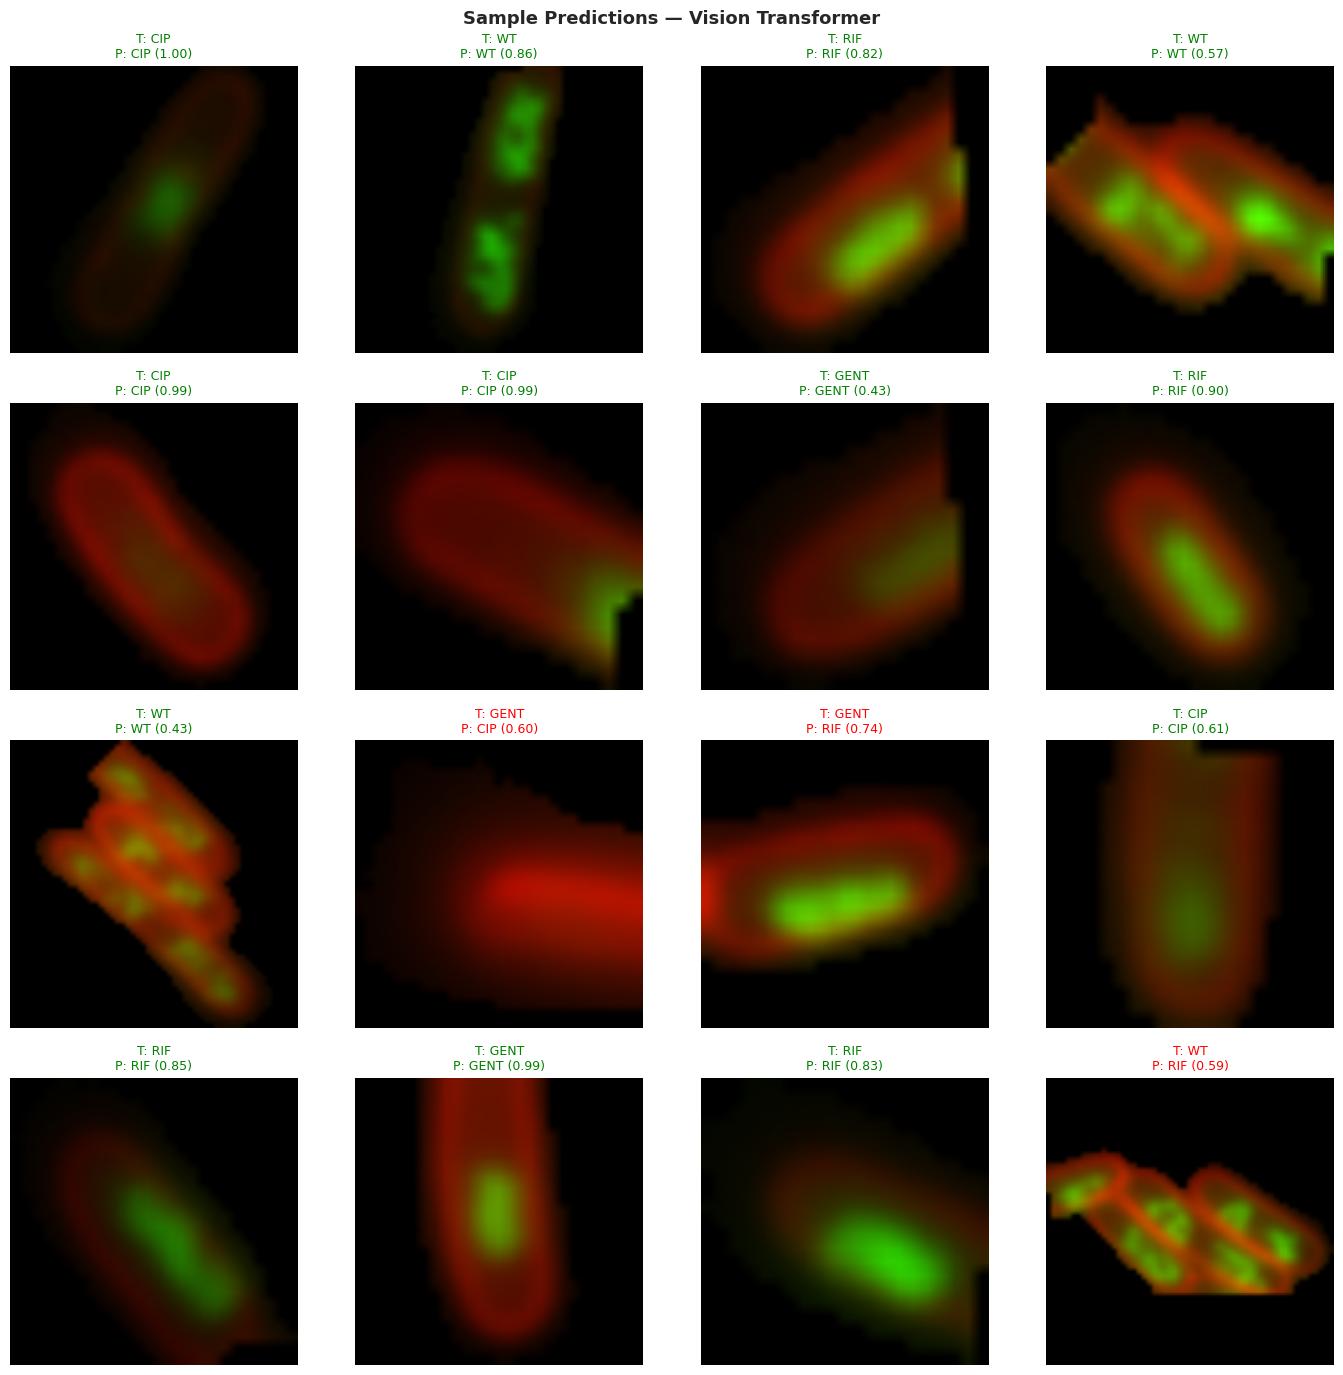

In [59]:
test_seg_dir = 'segmented images/test_segmented'
all_test_imgs = []

for cls_label in os.listdir(test_seg_dir):
    cls_path = os.path.join(test_seg_dir, cls_label)
    if os.path.isdir(cls_path):
        for fn in os.listdir(cls_path):
            if fn.lower().endswith('.png'):
                all_test_imgs.append((os.path.join(cls_path, fn), cls_label))

n_show = min(16, len(all_test_imgs))
selected = random.sample(all_test_imgs, n_show)

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle(f"Sample Predictions — {best_name}", fontsize=13, fontweight='bold')

# Map index → class name
idx_to_class = {v: k for k, v in train_gen.class_indices.items()}

for ax, (img_path, true_label) in zip(axes.flat, selected):
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    inp = cv2.resize(img_rgb, IMAGE_SIZE) / 255.0
    inp = np.expand_dims(inp, 0)

    prob = best_model.predict(inp, verbose=0)
    pred_idx = np.argmax(prob)
    pred_label = idx_to_class[pred_idx]
    conf = prob[0, pred_idx]

    color = 'green' if pred_label == true_label else 'red'
    ax.imshow(img_rgb)
    ax.set_title(f"T: {true_label}\nP: {pred_label} ({conf:.2f})",
                 color=color, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig("qualitative_predictions.png", bbox_inches='tight')
plt.show()

## **Summary Table**

In [60]:
summary_cols = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Cohen Kappa', 'MCC']
summary_df = metrics_df[summary_cols].sort_values('F1-Score', ascending=False).reset_index(drop=True)
summary_df.index += 1  # rank from 1

print("Final Leaderboard (Test Set — sorted by F1-Score):")
print(summary_df.to_string())

Final Leaderboard (Test Set — sorted by F1-Score):
                 Model  Accuracy  Precision  Recall  F1-Score  Cohen Kappa     MCC
1   Vision Transformer    0.8027     0.8456  0.7614    0.7995       0.7330  0.7343
2          DenseNet169    0.7948     0.8327  0.7535    0.7840       0.7206  0.7218
3  Fine Tuned DenseNet    0.7530     0.7957  0.7093    0.7471       0.6683  0.6707
4           Custom CNN    0.6403     0.6552  0.6218    0.5877       0.5132  0.5408


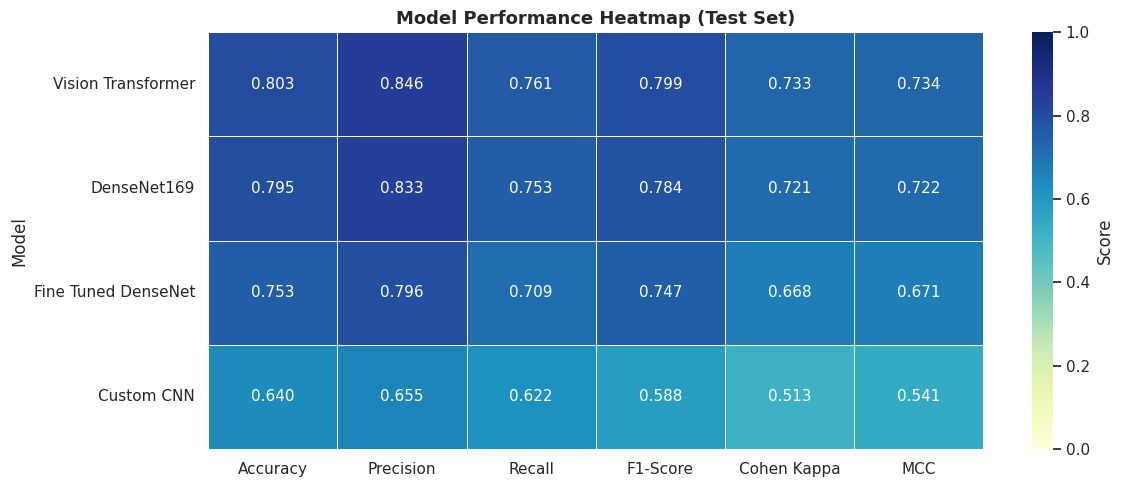

In [61]:
# Heatmap of all scores
fig, ax = plt.subplots(figsize=(12, 5))
heat_data = summary_df.set_index('Model')[['Accuracy','Precision','Recall','F1-Score','Cohen Kappa','MCC']]
sns.heatmap(heat_data, annot=True, fmt='.3f', cmap='YlGnBu', vmin=0, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Score'})
ax.set_title("Model Performance Heatmap (Test Set)", fontsize=13, fontweight='bold')
ax.set_ylabel("Model")
plt.tight_layout()
plt.savefig("final_leaderboard_heatmap.png", bbox_inches='tight')
plt.show()

In [62]:
print("Pipeline complete. All plots saved as PNG files.")
print(f"Best Model: {best_name}")
print(f"   Val Accuracy  : {best_row['Accuracy']:.4f}")
print(f"   Val F1-Score  : {best_row['F1-Score']:.4f}")
print(f"   Val Cohen Kappa: {best_row['Cohen Kappa']:.4f}")
print(f"   Val MCC       : {best_row['MCC']:.4f}")

Pipeline complete. All plots saved as PNG files.
Best Model: Vision Transformer
   Val Accuracy  : 0.8027
   Val F1-Score  : 0.7995
   Val Cohen Kappa: 0.7330
   Val MCC       : 0.7343
